# Kinase KD × selected CytoSignal LR score gene-level OLS

## Purpose

This notebook is the second-stage gene-level regression analysis for the kinase perturbation dataset with CytoSignal LR scores. It takes the top LR scores selected by `Kinase_CytoSignal_LR_ElasticNet_Screen.ipynb` and tests whether each LR score modifies the effect of a kinase KD on each gene.

The biological question is:

> Does the transcriptional effect of a kinase KD depend on the incoming spatial ligand–receptor microenvironment measured by a CytoSignal LR score?

## Input data

The notebook uses the same nine slide-level H5MU files as the screen notebook:

```text
slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
...
slide9_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
```

It also reads the candidate LR-score table from the first-stage screen:

```text
kinase_cytosignal_lr_elasticnet_screen_results_ctrl5000/candidate_lr_scores_for_single_lr_ols.csv
```

Each candidate row specifies:

```text
kinase target, radius, LR score
```

## Perturbation and control definition

This notebook uses the same kinase KD/control logic as the screen notebook and the earlier kinase analysis.

- KD-positive cells for kinase `K`: cells whose resolved `guides_passing_str` target set contains `K`.
- Controls: explicit NTC / negative-control-only cells.
- Other kinase KD cells are not used as controls.
- Mixed or multi-target cells containing `K` are KD-positive for `K`.

For each candidate model:

```text
model cells = KD-positive cells for kinase K + explicit NTC control cells
```

## Regression model

For each candidate kinase `K`, LR score `j`, radius `r`, and each gene `g`, the notebook fits:

\[
Y_g = \beta_0 + \beta_{KD} KD_K + \beta_{LR} LR_j(r) + \beta_{INT}\left(KD_K \times LR_j(r)\right) + \epsilon
\]

where:

- \(Y_g\) is gene expression;
- \(KD_K\) is 1 for cells carrying kinase `K` targeting guide and 0 for explicit NTC controls;
- \(LR_j(r)\) is the z-scored CytoSignal LR score at radius `r`;
- \(KD_K \times LR_j(r)\) is the interaction term.

## Interpretation of coefficients

- \(\beta_{KD}\): the kinase KD effect at the mean LR score.
- \(\beta_{LR}\): association between LR score and gene expression among the model cells.
- \(\beta_{INT}\): whether the kinase KD effect changes as the LR score changes.

The interaction coefficient is the key quantity:

```text
beta_interaction > 0
    high LR score makes the KD effect more positive / less negative

beta_interaction < 0
    high LR score makes the KD effect more negative / less positive
```

The notebook also reports conditional KD effects:

\[
\text{KD effect at low LR score} = \beta_{KD} - \beta_{INT}
\]

\[
\text{KD effect at mean LR score} = \beta_{KD}
\]

\[
\text{KD effect at high LR score} = \beta_{KD} + \beta_{INT}
\]

Because LR scores are z-scored within model cells, "low" and "high" correspond approximately to one standard deviation below or above the mean score.

## Gene and model filtering

A candidate model is skipped if:

- total model cell count is below `MIN_TOTAL_CELLS`;
- KD cell count is below `MIN_KD_CELLS`;
- control cell count is below `MIN_CONTROL_CELLS`;
- LR score standard deviation is below `MIN_LR_SD`.

A gene is tested only if its detection fraction among model cells is at least `MIN_DETECTION_FRACTION`.

## Computational strategy

For each candidate kinase × radius × LR-score model, the design matrix is fixed across genes. Therefore the notebook uses vectorized OLS to fit all genes at once:

\[
\hat{B} = (X^T X)^{-1} X^T Y
\]

This is much faster than fitting one ordinary least-squares model per gene in a Python loop.

Each candidate model is cached as a compressed CSV. If `FORCE_REFIT = False`, already-completed models are reused and not refit.

## Outputs

Main outputs are written to:

```text
/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top_lr_gene_level_ols_results
```

Important files:

- one `*_gene_level_ols.csv.gz` per kinase × radius × LR model;
- `gene_level_ols_fit_qc.csv`: model completion/skipping audit;
- `model_cell_audit.csv`: KD/control counts for candidate kinase targets;
- `interaction_summary.csv`: number of significant interaction genes per model;
- `spatial_effect_modification_candidates.csv`: top gene-level interaction candidates;
- `top_interaction_models.png`: QC plot of models with many significant interactions.

## Expected result

The desired result is a ranked set of kinase × LR-score × gene events where:

```text
fdr_interaction is significant
abs(beta_interaction) is large enough to be biologically interesting
conditional KD effects differ between low-score and high-score cells
```

These are candidate spatial effect-modification events: the effect of a kinase KD on a gene appears to depend on the incoming LR-score microenvironment.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import t as t_dist
from statsmodels.stats.multitest import multipletests

import anndata as ad
import mudata as mu

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 200)

## 1. Configuration

In [2]:
SLIDE_H5MU_DIR = Path('/scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu')
INPUT_H5MU_PATHS = {
    f'slide{i}': SLIDE_H5MU_DIR / f'slide{i}_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu'
    for i in range(1, 10)
}

SCREEN_DIR = Path('/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_elasticnet_screen_results_ctrl5000')
SCREEN_CANDIDATE_CSV = SCREEN_DIR / 'candidate_lr_scores_for_single_lr_ols.csv'
OUTPUT_DIR = Path('/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNA_MOD = 'rna'
LR_MOD = 'lr_cytosignal'
GUIDE_COLUMN = 'guides_passing_str'
EB_COLUMN = 'EB_cluster_manual'

RADIUS_LAYERS = {
    100: 'radius_100um',
    200: 'radius_200um',
    400: 'radius_400um',
}

NTC_ALIASES = {'NTC', 'NEGATIVE CONTROL', 'NEGATIVE_CONTROL', 'NON-TARGETING', 'NON_TARGETING', 'NONTARGETING'}
MISSING_GUIDE_VALUES = {'', 'nan', 'none', 'na', 'NA', 'NaN', '<NA>'}
EXCLUDE_TARGET_LABELS = {'UNASSIGNED', 'NO_CRISPR_DATA'}

MIN_KD_CELLS = 30
MIN_CONTROL_CELLS = 100
TOP_N_KINASE_KDS = None  # set e.g. 25 for a pilot run; None runs all eligible kinase targets

LR_MIN_GLOBAL_NONZERO_FRACTION = 0.005
LR_MIN_GLOBAL_SD = 1e-8
LR_MIN_APPROX_UNIQUE_VALUES = 2
LR_APPROX_UNIQUE_DECIMALS = 8
MIN_LR_NONZERO_FRACTION = 0.005
MIN_LR_SD = 1e-8
MAX_LR_SCORES_PER_MODEL = None

N_RNA_PCS = 30
TOP_VARIABLE_GENES_FOR_PCA = 8000
FORCE_RECOMPUTE_RNA_PCS = False

ELASTICNET_ALPHA = 0.01
ELASTICNET_L1_RATIO = 0.5
MAX_ITER = 5000
RANDOM_STATE = 20260729

TOP_LR_PER_TARGET_RADIUS_FOR_OLS = 5

print('Input H5MU files:')
for slide, path in INPUT_H5MU_PATHS.items():
    print(' ', slide, path)
print('Screen candidates:', SCREEN_CANDIDATE_CSV)
print('Output dir:', OUTPUT_DIR)


MAX_CANDIDATE_ROWS = None
MIN_DETECTION_FRACTION = 0.05
MIN_TOTAL_CELLS = 50
MIN_KD_CELLS = 30
MIN_CONTROL_CELLS = 100
MIN_LR_SD = 1e-8
FORCE_REFIT = False
FDR_THRESHOLD = 0.05
EFFECT_MOD_FDR_INTERACTION = 0.05
EFFECT_MOD_FDR_KD = 0.05
EFFECT_MOD_MIN_ABS_BETA_INTERACTION = 0.10
EFFECT_MOD_MIN_ABS_CONDITIONAL_DELTA = 0.20

Input H5MU files:
  slide1 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide2 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide2_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide3 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide3_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide4 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide4_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide5 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide5_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide6 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide6_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide7 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides

## 2. Helper functions

In [3]:
def safe_name(x):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(x))


def normalize_token(x):
    if pd.isna(x):
        return ''
    return str(x).strip()


def split_guides(value):
    text = normalize_token(value)
    if not text or text.lower() in {v.lower() for v in MISSING_GUIDE_VALUES}:
        return []
    return [p.strip() for p in re.split(r'[;,|]+', text) if p.strip()]


def infer_target_from_guide(guide):
    text = normalize_token(guide)
    if not text:
        return ''
    upper = text.upper()
    if upper in NTC_ALIASES or re.search(r'NEGATIVE|NON[-_ ]?TARGET|\bNTC\b', upper):
        return 'NTC'
    token = re.split(r'[|:]', text)[0]
    token = re.sub(r'([._-]?g?RNA)?[._-]?(guide)?[._-]?\d+$', '', token, flags=re.I)
    token = re.sub(r'[._-](sg|g)\d+$', '', token, flags=re.I)
    return token.strip(' ._-').upper()


def guide_mapping_from_uns(uns):
    mapping = {}
    if uns is None or 'guide_protospacers' not in uns or 'gene_names_from_guides' not in uns:
        return mapping
    guides = np.asarray(uns['guide_protospacers']).astype(str)
    targets = np.asarray(uns['gene_names_from_guides']).astype(str)
    if len(guides) != len(targets):
        # This is expected for some exported kinase objects. In that case guide names are parsed directly.
        return mapping
    for guide, target in zip(guides, targets):
        guide = normalize_token(guide)
        target = normalize_token(target).upper() or infer_target_from_guide(guide)
        if guide:
            mapping[guide] = target
    return mapping


def map_guides_to_targets(value, guide_map):
    guides = split_guides(value)
    mapped = {guide_map.get(g, infer_target_from_guide(g)).upper() for g in guides}
    mapped.discard('')
    targets = tuple(sorted((mapped - NTC_ALIASES) - EXCLUDE_TARGET_LABELS))
    is_ntc_only = bool(mapped & NTC_ALIASES) and not bool((mapped - NTC_ALIASES) - EXCLUDE_TARGET_LABELS)
    return targets, is_ntc_only


def get_lr_matrix_for_radius(lr, radius_um):
    layer = RADIUS_LAYERS[int(radius_um)]
    if layer in lr.layers:
        return lr.layers[layer]
    if int(radius_um) == 200:
        return lr.X
    raise KeyError(f'Missing LR layer for radius {radius_um}: {layer}')


def to_dense_float32(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


def dense_vector(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x).ravel()


def matrix_col_stats(X):
    if sp.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
        sd = np.sqrt(np.maximum(mean_sq - mean**2, 0))
        nonzero = np.asarray((X != 0).mean(axis=0)).ravel()
    else:
        arr = np.asarray(X)
        mean = arr.mean(axis=0)
        sd = arr.std(axis=0)
        nonzero = (arr != 0).mean(axis=0)
    return mean, sd, nonzero


def approx_unique_count_vector(x, decimals=8):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return 0
    return int(pd.Series(np.round(x, decimals)).nunique())


def lr_feature_qc_for_matrix(X, lr_var, radius_um):
    mean, sd, nonzero = matrix_col_stats(X)
    rows = []
    for j, name in enumerate(lr_var.index.astype(str)):
        rows.append({
            'radius_um': int(radius_um),
            'lr_var_name': name,
            'ligand_name': lr_var.iloc[j].get('ligand_name', np.nan),
            'receptor_name': lr_var.iloc[j].get('receptor_name', np.nan),
            'lr_name': lr_var.iloc[j].get('lr_name', name),
            'global_mean': float(mean[j]),
            'global_sd': float(sd[j]),
            'global_nonzero_fraction': float(nonzero[j]),
        })
    qc = pd.DataFrame(rows)
    qc['passes_global_qc'] = (
        qc['global_sd'].ge(LR_MIN_GLOBAL_SD)
        & qc['global_nonzero_fraction'].ge(LR_MIN_GLOBAL_NONZERO_FRACTION)
    )
    return qc


def fit_elasticnet_screen_for_target(target, radius_um, lr_matrix, lr_feature_qc, rna_pcs, metadata):
    kd_mask = metadata['target_sets'].map(lambda xs: target in xs).to_numpy(bool)
    ctrl_mask = metadata['is_control'].to_numpy(bool)
    use = kd_mask | ctrl_mask
    n_kd = int(kd_mask.sum())
    n_control = int(ctrl_mask.sum())
    if n_kd < MIN_KD_CELLS or n_control < MIN_CONTROL_CELLS:
        return pd.DataFrame(), {'status': 'skipped_low_group_cells', 'target': target, 'radius_um': radius_um, 'n_kd': n_kd, 'n_control': n_control}

    candidate_lr = lr_feature_qc.loc[lr_feature_qc['passes_global_qc'], 'lr_var_name'].tolist()
    lr_index = {name: i for i, name in enumerate(lr_feature_qc['lr_var_name'].astype(str))}
    cols = [lr_index[x] for x in candidate_lr]
    X_lr = lr_matrix[use, :][:, cols]
    _, subset_sd, subset_nonzero = matrix_col_stats(X_lr)
    keep = (subset_sd >= MIN_LR_SD) & (subset_nonzero >= MIN_LR_NONZERO_FRACTION)
    if MAX_LR_SCORES_PER_MODEL is not None and keep.sum() > MAX_LR_SCORES_PER_MODEL:
        order = np.argsort(-subset_sd[keep])[:MAX_LR_SCORES_PER_MODEL]
        keep_idx = np.flatnonzero(keep)[order]
    else:
        keep_idx = np.flatnonzero(keep)
    if len(keep_idx) == 0:
        return pd.DataFrame(), {'status': 'skipped_no_lr_features', 'target': target, 'radius_um': radius_um, 'n_kd': n_kd, 'n_control': n_control}

    kept_names = [candidate_lr[i] for i in keep_idx]
    X = to_dense_float32(X_lr[:, keep_idx])
    X = StandardScaler(with_mean=True, with_std=True).fit_transform(X)
    Y = np.asarray(rna_pcs[use, :], dtype=np.float32)

    model = MultiTaskElasticNet(alpha=ELASTICNET_ALPHA, l1_ratio=ELASTICNET_L1_RATIO, max_iter=MAX_ITER, random_state=RANDOM_STATE)
    model.fit(X, Y)
    coef = np.asarray(model.coef_)  # n_tasks x n_features
    importance = np.sqrt((coef ** 2).sum(axis=0))

    meta = lr_feature_qc.set_index('lr_var_name').reindex(kept_names)
    result = pd.DataFrame({
        'target': target,
        'radius_um': int(radius_um),
        'lr_var_name': kept_names,
        'elasticnet_importance': importance,
        'subset_lr_sd': subset_sd[keep_idx],
        'subset_lr_nonzero_fraction': subset_nonzero[keep_idx],
        'n_kd': n_kd,
        'n_control': n_control,
    })
    for col in ['ligand_name', 'receptor_name', 'lr_name']:
        if col in meta.columns:
            result[col] = meta[col].to_numpy()
    result = result.sort_values('elasticnet_importance', ascending=False, ignore_index=True)
    qc = {'status': 'completed', 'target': target, 'radius_um': radius_um, 'n_kd': n_kd, 'n_control': n_control, 'n_lr_features': int(len(result))}
    return result, qc



def get_control_mask(metadata):
    return metadata['is_control'].to_numpy(bool)


def get_target_mask(metadata, target):
    target = str(target).upper()
    return metadata['target_sets'].map(lambda xs: target in xs).to_numpy(bool)


def get_gene_names(rna):
    return np.asarray(rna.var_names.astype(str))


def vectorized_ols_one_lr(rna, cell_idx, kd_binary, lr_score, min_detection_fraction=0.05):
    n = len(cell_idx)
    if n < MIN_TOTAL_CELLS:
        return pd.DataFrame(), {'status': 'skipped_low_total_cells', 'n_cells': n}
    n_kd = int(kd_binary.sum())
    n_control = int(n - n_kd)
    if n_kd < MIN_KD_CELLS or n_control < MIN_CONTROL_CELLS:
        return pd.DataFrame(), {'status': 'skipped_low_group_cells', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control}
    lr_score = np.asarray(lr_score, dtype=float)
    lr_sd = float(np.nanstd(lr_score))
    if not np.isfinite(lr_sd) or lr_sd < MIN_LR_SD:
        return pd.DataFrame(), {'status': 'skipped_constant_lr_score', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control, 'lr_sd': lr_sd}

    lr_z = (lr_score - np.nanmean(lr_score)) / lr_sd
    kd = np.asarray(kd_binary, dtype=float)
    interaction = kd * lr_z
    X = np.column_stack([np.ones(n), kd, lr_z, interaction])
    p = X.shape[1]
    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(XtX)
    pinv = XtX_inv @ X.T

    Y = rna.X[cell_idx, :]
    if sp.issparse(Y):
        detection = np.asarray((Y > 0).mean(axis=0)).ravel()
        keep_genes = detection >= min_detection_fraction
        Y = Y[:, keep_genes].toarray()
    else:
        detection = np.asarray((Y > 0).mean(axis=0)).ravel()
        keep_genes = detection >= min_detection_fraction
        Y = np.asarray(Y[:, keep_genes])
    gene_names = get_gene_names(rna)[keep_genes]
    detection = detection[keep_genes]
    if Y.shape[1] == 0:
        return pd.DataFrame(), {'status': 'skipped_no_detected_genes', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control, 'lr_sd': lr_sd}

    Y = Y.astype(float, copy=False)
    betas = pinv @ Y
    residuals = Y - X @ betas
    dof = n - p
    sigma2 = (residuals ** 2).sum(axis=0) / dof
    se = np.sqrt(np.outer(np.diag(XtX_inv), sigma2))
    tvals = betas / se
    pvals = 2 * t_dist.sf(np.abs(tvals), dof)

    fdr_kd = multipletests(pvals[1, :], method='fdr_bh')[1]
    fdr_score = multipletests(pvals[2, :], method='fdr_bh')[1]
    fdr_interaction = multipletests(pvals[3, :], method='fdr_bh')[1]

    out = pd.DataFrame({
        'gene': gene_names,
        'detection_fraction': detection,
        'beta_kd': betas[1, :],
        'se_kd': se[1, :],
        'p_kd': pvals[1, :],
        'beta_score': betas[2, :],
        'se_score': se[2, :],
        'p_score': pvals[2, :],
        'beta_interaction': betas[3, :],
        'se_interaction': se[3, :],
        'p_interaction': pvals[3, :],
        'fdr_kd': fdr_kd,
        'fdr_score': fdr_score,
        'fdr_interaction': fdr_interaction,
        'score_mean_raw': float(np.nanmean(lr_score)),
        'score_sd_raw': lr_sd,
        'n_kd': n_kd,
        'n_control': n_control,
    })
    out['conditional_kd_effect_low_score'] = out['beta_kd'] - out['beta_interaction']
    out['conditional_kd_effect_mid_score'] = out['beta_kd']
    out['conditional_kd_effect_high_score'] = out['beta_kd'] + out['beta_interaction']
    return out, {'status': 'completed', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control, 'lr_sd': lr_sd, 'n_genes': int(len(out))}

## 3. Load nine slide H5MU files and selected LR candidates

In [4]:
assert all(path.is_file() for path in INPUT_H5MU_PATHS.values()), INPUT_H5MU_PATHS

mdata_by_slide = {}
rna_blocks = []
lr_blocks = []
guide_map = {}
slide_qc_rows = []

for slide, path in INPUT_H5MU_PATHS.items():
    print(f'Loading {slide}: {path}')
    m = mu.read_h5mu(path)
    r = m.mod[RNA_MOD]
    l = m.mod[LR_MOD]
    common_cells = r.obs_names.intersection(l.obs_names)
    r = r[common_cells, :].copy()
    l = l[common_cells, :].copy()

    gm = guide_mapping_from_uns(r.uns)
    guide_map.update(gm)

    r.obs['source_slide'] = slide
    l.obs['source_slide'] = slide
    r.obs_names = [f'{slide}::{x}' for x in r.obs_names.astype(str)]
    l.obs_names = [f'{slide}::{x}' for x in l.obs_names.astype(str)]

    rna_blocks.append(r)
    lr_blocks.append(l)
    mdata_by_slide[slide] = m
    slide_qc_rows.append({'slide': slide, 'path': str(path), 'n_common_cells': len(common_cells), 'rna_genes': r.n_vars, 'lr_scores': l.n_vars, 'guide_map_size': len(gm)})

rna = ad.concat(rna_blocks, axis=0, join='inner', merge='same', index_unique=None)
lr = ad.concat(lr_blocks, axis=0, join='inner', merge='same', index_unique=None)
slide_qc = pd.DataFrame(slide_qc_rows)

print('Combined RNA:', rna.shape)
print('Combined LR:', lr.shape)
print('Guide mappings loaded:', len(guide_map), '(fallback guide-name parsing is used when mappings are absent)')
display(slide_qc)
display(lr.var.head())

(OUTPUT_DIR / 'metadata_inspection.json').write_text(json.dumps({
    'input_h5mu_paths': {k: str(v) for k, v in INPUT_H5MU_PATHS.items()},
    'combined_rna_shape': list(rna.shape),
    'combined_lr_shape': list(lr.shape),
    'lr_layers': list(lr.layers.keys()),
    'rna_obs_columns': list(rna.obs.columns),
    'slide_qc': slide_qc.to_dict(orient='records'),
}, indent=2))


assert SCREEN_CANDIDATE_CSV.is_file(), SCREEN_CANDIDATE_CSV
candidates = pd.read_csv(SCREEN_CANDIDATE_CSV)
if MAX_CANDIDATE_ROWS is not None:
    candidates = candidates.head(MAX_CANDIDATE_ROWS).copy()
required_cols = {'target', 'radius_um', 'lr_var_name'}
missing = required_cols - set(candidates.columns)
assert not missing, missing
candidates['radius_um'] = candidates['radius_um'].astype(int)
candidates['target'] = candidates['target'].astype(str).str.upper()
candidates['lr_var_name'] = candidates['lr_var_name'].astype(str)
if 'elasticnet_importance' not in candidates.columns:
    candidates['elasticnet_importance'] = 0.0
candidates['elasticnet_importance'] = pd.to_numeric(candidates['elasticnet_importance'], errors='coerce').fillna(0.0)

# Keep only the top N LR scores within each kinase target × radius, based on elastic-net importance.
candidates = (
    candidates
    .sort_values(['target', 'radius_um', 'elasticnet_importance'], ascending=[True, True, False])
    .drop_duplicates(['target', 'radius_um', 'lr_var_name'])
    .groupby(['target', 'radius_um'], as_index=False, group_keys=False)
    .head(TOP_LR_PER_TARGET_RADIUS_FOR_OLS)
    .reset_index(drop=True)
)
candidates.to_csv(OUTPUT_DIR / 'input_candidate_lr_scores.csv', index=False)
print('Top LR scores per target × radius:', TOP_LR_PER_TARGET_RADIUS_FOR_OLS)
print('Candidate target × radius × LR rows:', len(candidates))
print('Expected if every target-radius has enough LR scores:', candidates['target'].nunique() * candidates['radius_um'].nunique() * TOP_LR_PER_TARGET_RADIUS_FOR_OLS)
display(candidates.head(30))

Loading slide1: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide2: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide2_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide3: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide3_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide4: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide4_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide5: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide5_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide6: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide6_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide7: /scratch/luvul_root/luvul0/luvul/cyt

,slide,path,n_common_cells,rna_genes,lr_scores,guide_map_size
0,slide1,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,2585,19408,263,0
1,slide2,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,11912,29172,519,0
2,slide3,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,5220,26531,442,0
3,slide4,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,3668,25565,409,0
4,slide5,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,6312,26214,426,0
5,slide6,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,7865,28048,488,0
6,slide7,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,8140,27897,487,0
7,slide8,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,17567,29978,531,0
8,slide9,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,6946,22760,335,0


,lr_name,lr_type
interaction_id,,
CPI-CS0107C51C6,BMP4_BMPR1B+BMPR2,diffusion
CPI-CS012D15A88,BMP4_BMPR1A+ACVR2A,diffusion
CPI-CS01319F57A,BMP8A_BMPR1B+ACVR2A,diffusion
CPI-CS017A50010,BMP8A_BMPR1A+ACVR2B,diffusion
CPI-CS01A4D7E2F,BMP5_BMPR1B+ACVR2A,diffusion


Top LR scores per target × radius: 5
Candidate target × radius × LR rows: 4080
Expected if every target-radius has enough LR scores: 4080


,target,radius_um,lr_var_name,elasticnet_importance,subset_lr_sd,subset_lr_nonzero_fraction,n_kd,n_control,ligand_name,receptor_name,lr_name
0,AAK1,100,CPI-CS040AEB4A0,1.022911,0.403759,0.942807,88,5000,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1
1,AAK1,100,CPI-SS01F67987A,0.919856,0.505350,0.970715,88,5000,NaN,NaN,FGF2_FGFR1
2,AAK1,100,CPI-SS006C6537E,0.835005,0.239638,0.941234,88,5000,NaN,NaN,MDK_LRP1
3,AAK1,100,CPI-SS0472C478C,0.758634,0.346377,0.967964,88,5000,NaN,NaN,BMP7_PTPRK
4,AAK1,100,CPI-SS055E061C9,0.743793,0.158446,0.932586,88,5000,NaN,NaN,FAM3C_LAMP1
5,AAK1,200,CPI-SS01F67987A,1.021524,0.410771,0.990959,88,5000,NaN,NaN,FGF2_FGFR1
6,AAK1,200,CPI-CS040AEB4A0,0.953096,0.325645,0.971108,88,5000,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1
7,AAK1,200,CPI-SS006C6537E,0.942641,0.179199,0.976219,88,5000,NaN,NaN,MDK_LRP1
8,AAK1,200,CPI-SS055E061C9,0.701808,0.117615,0.977005,88,5000,NaN,NaN,FAM3C_LAMP1
9,AAK1,200,CPI-SS0472C478C,0.690077,0.257334,0.989387,88,5000,NaN,NaN,BMP7_PTPRK


## 4. Control/KD QC

In [5]:
assert GUIDE_COLUMN in rna.obs.columns, GUIDE_COLUMN

target_info = [map_guides_to_targets(x, guide_map) for x in rna.obs[GUIDE_COLUMN].to_numpy()]
rna.obs['target_sets'] = pd.Series([x[0] for x in target_info], index=rna.obs_names, dtype='object')
rna.obs['is_control'] = pd.Series([x[1] for x in target_info], index=rna.obs_names, dtype=bool)
metadata = pd.DataFrame({
    'cell_id': rna.obs_names.astype(str),
    'source_slide': rna.obs['source_slide'].astype(str).to_numpy() if 'source_slide' in rna.obs else '',
    'target_sets': rna.obs['target_sets'].to_numpy(),
    'is_control': rna.obs['is_control'].to_numpy(bool),
})
control_mask = get_control_mask(metadata)
print('Controls:', int(control_mask.sum()))
print('Targets in candidate table:', candidates['target'].nunique())

audit = []
for target, group in candidates.groupby('target'):
    kd_mask = get_target_mask(metadata, target)
    audit.append({'target': target, 'n_kd': int(kd_mask.sum()), 'n_control': int(control_mask.sum()), 'n_candidate_lr': len(group)})
model_cell_audit = pd.DataFrame(audit).sort_values('n_kd', ascending=False, ignore_index=True)
model_cell_audit.to_csv(OUTPUT_DIR / 'model_cell_audit.csv', index=False)
display(model_cell_audit.head(50))

Controls: 38554
Targets in candidate table: 272


,target,n_kd,n_control,n_candidate_lr
0,TTBK2,936,38554,15
1,ROCK2,852,38554,15
2,PTK2,686,38554,15
3,EPHA6,506,38554,15
4,MAPK8,505,38554,15
5,MAP4K4,455,38554,15
6,MAP3K21,416,38554,15
7,STK39,413,38554,15
8,MAPKAPK3,411,38554,15
9,MYLK3,399,38554,15


## 5. Fit selected single-LR gene-level OLS models

In [6]:
lr_index = {name: i for i, name in enumerate(lr.var_names.astype(str))}
all_qc = []

for _, row in candidates.iterrows():
    target = str(row['target']).upper()
    radius_um = int(row['radius_um'])
    lr_var_name = str(row['lr_var_name'])
    if lr_var_name not in lr_index:
        all_qc.append({'target': target, 'radius_um': radius_um, 'lr_var_name': lr_var_name, 'status': 'missing_lr_var'})
        continue

    out_csv = OUTPUT_DIR / f'{safe_name(target)}__r{radius_um}um__{safe_name(lr_var_name)}_gene_level_ols.csv.gz'
    out_json = OUTPUT_DIR / f'{safe_name(target)}__r{radius_um}um__{safe_name(lr_var_name)}_gene_level_ols_qc.json'
    if out_csv.is_file() and out_json.is_file() and not FORCE_REFIT:
        all_qc.append(json.loads(out_json.read_text()))
        continue

    kd_mask = get_target_mask(metadata, target)
    ctrl_mask = get_control_mask(metadata)
    use = kd_mask | ctrl_mask
    cell_idx = np.flatnonzero(use)
    kd_binary = kd_mask[cell_idx].astype(float)
    lr_matrix = get_lr_matrix_for_radius(lr, radius_um)
    lr_score = dense_vector(lr_matrix[cell_idx, lr_index[lr_var_name]])

    print('Fitting', target, radius_um, lr_var_name, 'cells', len(cell_idx), 'kd', int(kd_binary.sum()))
    result, qc = vectorized_ols_one_lr(rna, cell_idx, kd_binary, lr_score, MIN_DETECTION_FRACTION)
    qc.update({'target': target, 'radius_um': radius_um, 'lr_var_name': lr_var_name})
    for col in ['ligand_name', 'receptor_name', 'lr_name', 'elasticnet_importance']:
        if col in row.index:
            qc[col] = row[col]
            if not result.empty:
                result[col] = row[col]
    if not result.empty:
        result.insert(0, 'target', target)
        result.insert(1, 'radius_um', radius_um)
        result.insert(2, 'lr_var_name', lr_var_name)
        result.to_csv(out_csv, index=False, compression='gzip')
    else:
        pd.DataFrame().to_csv(out_csv, index=False, compression='gzip')
    out_json.write_text(json.dumps(qc, indent=2, default=str))
    all_qc.append(qc)

fit_qc = pd.DataFrame(all_qc)
fit_qc.to_csv(OUTPUT_DIR / 'gene_level_ols_fit_qc.csv', index=False)
display(fit_qc['status'].value_counts(dropna=False).to_frame('n'))
display(fit_qc.head(30))

Fitting WNK4 200 CPI-CS040AEB4A0 cells 38718 kd 164
Fitting WNK4 200 CPI-SS006C6537E cells 38718 kd 164
Fitting WNK4 200 CPI-SS01F67987A cells 38718 kd 164
Fitting WNK4 200 CPI-SS0984C2931 cells 38718 kd 164
Fitting WNK4 200 CPI-SS055E061C9 cells 38718 kd 164
Fitting WNK4 400 CPI-CS040AEB4A0 cells 38718 kd 164
Fitting WNK4 400 CPI-SS01F67987A cells 38718 kd 164
Fitting WNK4 400 CPI-SS03F0B666C cells 38718 kd 164
Fitting WNK4 400 CPI-SS09A36B221 cells 38718 kd 164
Fitting WNK4 400 CPI-CS0107C51C6 cells 38718 kd 164
Fitting YES1 100 CPI-CS040AEB4A0 cells 38642 kd 88
Fitting YES1 100 CPI-SS01F67987A cells 38642 kd 88
Fitting YES1 100 CPI-SS006C6537E cells 38642 kd 88
Fitting YES1 100 CPI-CS028ACED72 cells 38642 kd 88
Fitting YES1 100 CPI-SS055E061C9 cells 38642 kd 88
Fitting YES1 200 CPI-CS040AEB4A0 cells 38642 kd 88
Fitting YES1 200 CPI-SS01F67987A cells 38642 kd 88
Fitting YES1 200 CPI-SS006C6537E cells 38642 kd 88
Fitting YES1 200 CPI-SS055E061C9 cells 38642 kd 88
Fitting YES1 200 CPI-

,n
status,
completed,4080


,status,n_cells,n_kd,n_control,lr_sd,n_genes,target,radius_um,lr_var_name,ligand_name,receptor_name,lr_name,elasticnet_importance
0,completed,38642,88,38554,0.404175,8806,AAK1,100,CPI-CS040AEB4A0,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.022911
1,completed,38642,88,38554,0.502845,8806,AAK1,100,CPI-SS01F67987A,NaN,NaN,FGF2_FGFR1,0.919856
2,completed,38642,88,38554,0.245018,8806,AAK1,100,CPI-SS006C6537E,NaN,NaN,MDK_LRP1,0.835005
3,completed,38642,88,38554,0.343282,8806,AAK1,100,CPI-SS0472C478C,NaN,NaN,BMP7_PTPRK,0.758634
4,completed,38642,88,38554,0.155431,8806,AAK1,100,CPI-SS055E061C9,NaN,NaN,FAM3C_LAMP1,0.743793
5,completed,38642,88,38554,0.411407,8806,AAK1,200,CPI-SS01F67987A,NaN,NaN,FGF2_FGFR1,1.021524
6,completed,38642,88,38554,0.329918,8806,AAK1,200,CPI-CS040AEB4A0,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,0.953096
7,completed,38642,88,38554,0.183073,8806,AAK1,200,CPI-SS006C6537E,NaN,NaN,MDK_LRP1,0.942641
8,completed,38642,88,38554,0.119764,8806,AAK1,200,CPI-SS055E061C9,NaN,NaN,FAM3C_LAMP1,0.701808
9,completed,38642,88,38554,0.263468,8806,AAK1,200,CPI-SS0472C478C,NaN,NaN,BMP7_PTPRK,0.690077


## 6. Summarize significant interactions and top events

Loaded gene-level rows: 35972955
Interaction summary rows: 4080
Spatial effect-modification candidates: 24782


,target,radius_um,lr_var_name,n_genes_tested,n_significant_interaction,min_fdr_interaction,max_abs_beta_interaction,ligand_name,receptor_name
0,EPHA6,400,CPI-SS055E061C9,8849,1511,2.390587e-13,0.367867,NaN,NaN
1,TTBK2,400,CPI-SS055E061C9,8899,1476,9.599794e-11,0.201595,NaN,NaN
2,PTK2,400,CPI-CS040AEB4A0,8864,1474,2.462962e-20,0.220082,NaN,NaN
3,TTBK2,400,CPI-CS040AEB4A0,8899,1443,1.332703e-08,0.171653,NaN,NaN
4,PTK2,200,CPI-CS040AEB4A0,8864,1423,1.889962e-18,0.222231,NaN,NaN
5,ROCK2,400,CPI-CS040AEB4A0,8894,1161,1.624377e-11,0.182890,NaN,NaN
6,PTK2,400,CPI-SS055E061C9,8864,1064,2.453069e-08,0.227430,NaN,NaN
7,TTBK2,200,CPI-CS040AEB4A0,8899,1053,2.296830e-08,0.159315,NaN,NaN
8,PTK2,100,CPI-CS040AEB4A0,8864,943,5.866187e-15,0.209172,NaN,NaN
9,ROCK2,200,CPI-CS040AEB4A0,8894,747,6.166473e-09,0.161015,NaN,NaN


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd,se_kd,p_kd,beta_score,se_score,p_score,beta_interaction,se_interaction,p_interaction,fdr_kd,fdr_score,fdr_interaction,score_mean_raw,score_sd_raw,n_kd,n_control,conditional_kd_effect_low_score,conditional_kd_effect_mid_score,conditional_kd_effect_high_score,ligand_name,receptor_name,lr_name,elasticnet_importance,conditional_delta_high_minus_low,rank_score
0,MAST3,400,CPI-SS0472C478C,MALAT1,0.994221,0.274660,0.148389,6.418588e-02,0.204623,0.003949,0.000000e+00,-0.703056,0.081587,7.111234e-18,7.304188e-01,0.000000e+00,6.260730e-14,0.651535,0.213195,32,38554,0.977716,0.274660,-0.428397,NaN,NaN,BMP7_PTPRK,0.847006,-1.406113,9.282718
1,EPHA6,400,CPI-CS0D238C22B,LINC00378,0.090271,0.039344,0.014037,5.068475e-03,0.058559,0.001586,2.175610e-293,0.162612,0.012037,1.711863e-41,1.878967e-02,3.208662e-290,1.514828e-37,0.199248,0.152145,506,38554,-0.123268,0.039344,0.201956,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.685160,0.325225,5.987329
2,MERTK,400,CPI-SS055E061C9,EEF1A1,0.928372,-0.498101,0.076078,5.932854e-11,0.421790,0.003906,0.000000e+00,-0.401785,0.047150,1.632198e-17,1.380812e-07,0.000000e+00,1.438293e-13,0.189223,0.097416,104,38554,-0.096316,-0.498101,-0.899886,NaN,NaN,FAM3C_LAMP1,0.654341,-0.803569,5.159781
3,FLT4,100,CPI-CS0D238C22B,CDH18,0.152294,0.248174,0.064366,1.156067e-04,0.026034,0.002249,6.050348e-31,0.316291,0.035340,3.711760e-19,3.391900e-02,9.492899e-30,8.167728e-16,0.164369,0.205278,49,38554,-0.068117,0.248174,0.564466,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.544788,0.632583,4.772173
4,MAP3K2,400,CPI-SS01F67987A,AHRR,0.058268,0.042449,0.020991,4.315915e-02,0.006960,0.000833,6.747856e-17,0.226183,0.021793,3.353816e-25,7.087566e-01,1.568917e-16,2.953035e-21,0.987667,0.345611,61,38554,-0.183734,0.042449,0.268632,NaN,NaN,FGF2_FGFR1,0.922825,0.452366,4.643473
5,EPHA6,400,CPI-SS055E061C9,MALAT1,0.994342,0.447802,0.036059,2.418915e-35,0.117465,0.004021,1.360279e-185,0.367867,0.043469,2.701533e-17,1.070249e-31,3.439173e-184,2.390587e-13,0.189088,0.097004,506,38554,0.079935,0.447802,0.815670,NaN,NaN,FAM3C_LAMP1,0.766755,0.735735,4.643037
6,MAST3,400,CPI-CS040AEB4A0,MALAT1,0.994221,0.166851,0.144933,2.496463e-01,0.094149,0.004051,1.194829e-118,0.844020,0.135905,5.339312e-10,8.450058e-01,1.153429e-117,4.700731e-06,0.560444,0.285541,32,38554,-0.677169,0.166851,1.010871,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.009542,1.688040,4.496799
7,EPHA6,400,CPI-CS0D238C22B,DSCAM,0.160164,0.080126,0.020170,7.124494e-05,0.084398,0.002279,3.904802e-295,0.187025,0.017296,3.255859e-27,5.773320e-04,6.910719e-292,9.603700e-24,0.199248,0.152145,506,38554,-0.106900,0.080126,0.267151,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.685160,0.374051,4.304869
8,BMP2K,200,CPI-SS006C6537E,NRIP1,0.224342,0.288865,0.044620,9.664400e-11,0.010327,0.002012,2.867493e-07,0.453950,0.060760,8.118088e-14,1.936100e-07,3.995531e-07,7.151224e-10,0.292299,0.183038,79,38554,-0.165084,0.288865,0.742815,NaN,NaN,MDK_LRP1,0.761895,0.907900,4.151653
9,PTK2,400,CPI-CS040AEB4A0,AC068587.4,0.501223,0.379478,0.024866,1.976872e-52,0.040521,0.003293,9.885873e-35,0.220082,0.022645,2.661583e-22,6.258211e-50,2.277245e-34,1.083301e-18,0.560636,0.286060,686,38554,0.159396,0.379478,0.599560,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.171940,0.440164,3.953829


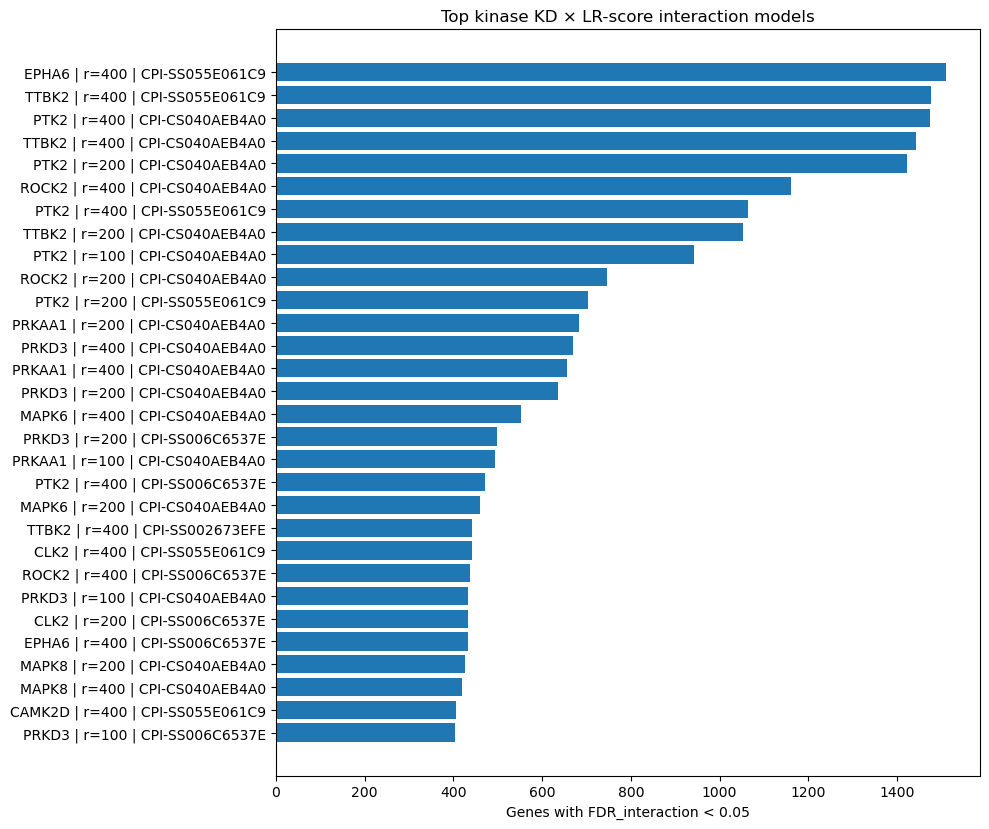

In [7]:
result_files = sorted(OUTPUT_DIR.glob('*_gene_level_ols.csv.gz'))
frames = []
for path in result_files:
    try:
        df = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        continue
    if not df.empty and {'target', 'radius_um', 'lr_var_name', 'gene'}.issubset(df.columns):
        frames.append(df)
all_model_results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print('Loaded gene-level rows:', len(all_model_results))

if all_model_results.empty:
    interaction_summary = pd.DataFrame()
    spatial_effect_modification_candidates = pd.DataFrame()
else:
    interaction_summary = (
        all_model_results.groupby(['target', 'radius_um', 'lr_var_name'], as_index=False)
        .agg(
            n_genes_tested=('gene', 'nunique'),
            n_significant_interaction=('fdr_interaction', lambda x: int((x < FDR_THRESHOLD).sum())),
            min_fdr_interaction=('fdr_interaction', 'min'),
            max_abs_beta_interaction=('beta_interaction', lambda x: float(np.nanmax(np.abs(x)))),
            ligand_name=('ligand_name', 'first') if 'ligand_name' in all_model_results.columns else ('gene', 'size'),
            receptor_name=('receptor_name', 'first') if 'receptor_name' in all_model_results.columns else ('gene', 'size'),
        )
        .sort_values(['n_significant_interaction', 'min_fdr_interaction'], ascending=[False, True], ignore_index=True)
    )

    candidates_mask = (
        all_model_results['fdr_interaction'].lt(EFFECT_MOD_FDR_INTERACTION)
        & (
            all_model_results['beta_interaction'].abs().ge(EFFECT_MOD_MIN_ABS_BETA_INTERACTION)
            | (all_model_results['conditional_kd_effect_high_score'] - all_model_results['conditional_kd_effect_low_score']).abs().ge(EFFECT_MOD_MIN_ABS_CONDITIONAL_DELTA)
        )
    )
    spatial_effect_modification_candidates = all_model_results.loc[candidates_mask].copy()
    spatial_effect_modification_candidates['conditional_delta_high_minus_low'] = (
        spatial_effect_modification_candidates['conditional_kd_effect_high_score']
        - spatial_effect_modification_candidates['conditional_kd_effect_low_score']
    )
    spatial_effect_modification_candidates['rank_score'] = (
        -np.log10(spatial_effect_modification_candidates['fdr_interaction'].clip(lower=1e-300))
        * spatial_effect_modification_candidates['beta_interaction'].abs()
    )
    spatial_effect_modification_candidates = spatial_effect_modification_candidates.sort_values('rank_score', ascending=False, ignore_index=True)

interaction_summary.to_csv(OUTPUT_DIR / 'interaction_summary.csv', index=False)
spatial_effect_modification_candidates.to_csv(OUTPUT_DIR / 'spatial_effect_modification_candidates.csv', index=False)

print('Interaction summary rows:', len(interaction_summary))
print('Spatial effect-modification candidates:', len(spatial_effect_modification_candidates))
display(interaction_summary.head(30))
display(spatial_effect_modification_candidates.head(50))

if not interaction_summary.empty:
    plot_df = interaction_summary.head(30).iloc[::-1]
    labels = plot_df['target'].astype(str) + ' | r=' + plot_df['radius_um'].astype(str) + ' | ' + plot_df['lr_var_name'].astype(str)
    fig, ax = plt.subplots(figsize=(10, max(5, 0.28 * len(plot_df))))
    ax.barh(labels, plot_df['n_significant_interaction'])
    ax.set_xlabel(f'Genes with FDR_interaction < {FDR_THRESHOLD}')
    ax.set_title('Top kinase KD × LR-score interaction models')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'top_interaction_models.png', dpi=200)
    plt.show()

## Post-hoc project-wide FDR and project-wide candidate tables

This section does **not** refit any model and does not modify the cached
gene-level result files. Benjamini–Hochberg correction is recomputed across
the full project separately for each coefficient family.

The new significant-interaction and top-event tables are selected using
`fdr_interaction_projectwide < PROJECTWIDE_FDR_ALPHA`. Existing model-wise FDR
columns and existing candidate tables are retained for comparison.


In [8]:
import sys
_PROJECTWIDE_HELPER_DIR = Path('/home/luvul/non-autonomous_analysis')
if str(_PROJECTWIDE_HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(_PROJECTWIDE_HELPER_DIR))
from projectwide_fdr import compute_projectwide_fdr

PROJECTWIDE_FDR_ALPHA = 0.05
PROJECTWIDE_TOP_N_PER_MODEL = 50
PROJECTWIDE_FDR_ROOT = OUTPUT_DIR / 'projectwide_fdr_posthoc'

projectwide_result_files = sorted(OUTPUT_DIR.glob('*_gene_level_ols.csv.gz'))
projectwide_input = pd.read_csv(OUTPUT_DIR / 'input_candidate_lr_scores.csv')
projectwide_fit_qc_path = OUTPUT_DIR / 'gene_level_ols_fit_qc.csv'
if not projectwide_fit_qc_path.is_file():
    raise RuntimeError(
        'The model-fitting loop has not completed. Run this post-hoc section '
        'only after gene_level_ols_fit_qc.csv has been written.'
    )
projectwide_fit_qc = pd.read_csv(projectwide_fit_qc_path)
expected_projectwide_files = len(projectwide_input)
if len(projectwide_fit_qc) != expected_projectwide_files:
    raise RuntimeError(
        f'Incomplete fitting audit: {len(projectwide_fit_qc):,} rows found, '
        f'{expected_projectwide_files:,} expected.'
    )

projectwide_fdr_result = compute_projectwide_fdr(
    result_files=projectwide_result_files,
    output_root=PROJECTWIDE_FDR_ROOT,
    pvalue_to_fdr={
        'p_kd': 'fdr_kd_projectwide',
        'p_score': 'fdr_score_projectwide',
        'p_interaction': 'fdr_interaction_projectwide',
    },
    group_columns=['target', 'radius_um', 'lr_var_name'],
    identity_columns=['target', 'radius_um', 'lr_var_name', 'gene'],
    interaction_p_column='p_interaction',
    interaction_fdr_column='fdr_interaction_projectwide',
    alpha=PROJECTWIDE_FDR_ALPHA,
    top_n_per_group=PROJECTWIDE_TOP_N_PER_MODEL,
    expected_source_file_count=expected_projectwide_files,
    force=False,
)

print('Project-wide FDR status:', projectwide_fdr_result['status'])
print('Project-wide output directory:', projectwide_fdr_result['run_dir'])
display(projectwide_fdr_result['qc'])
display(projectwide_fdr_result['summary'].head(50))
display(projectwide_fdr_result['top_events'].head(50))


Project-wide FDR status: completed
Project-wide output directory: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_fdr_posthoc/90fa9567630f5f9f


,pvalue_family,projectwide_fdr_column,n_total_rows,n_valid_tests,n_invalid_tests,n_projectwide_significant,minimum_p_value,minimum_projectwide_fdr,alpha
0,p_kd,fdr_kd_projectwide,35972955,35972955,0,4289131,3.807619e-87,1.369713e-79,0.05
1,p_score,fdr_score_projectwide,35972955,35972955,0,32951291,0.000000e+00,0.000000e+00,0.05
2,p_interaction,fdr_interaction_projectwide,35972955,35972955,0,21633,1.711863e-41,6.158078e-34,0.05


,target,radius_um,lr_var_name,n_genes_tested,n_projectwide_significant_interactions,minimum_p_interaction,minimum_fdr_interaction_projectwide,maximum_abs_beta_interaction
0,PTK2,400,CPI-CS040AEB4A0,8864,388,2.778612e-24,9.086807e-18,0.220082
1,PTK2,200,CPI-CS040AEB4A0,8864,349,4.071204e-22,6.656965e-16,0.222231
2,TTBK2,400,CPI-SS055E061C9,8899,291,1.225816e-14,4.045526e-09,0.201595
3,TTBK2,400,CPI-CS040AEB4A0,8899,276,1.497587e-12,2.394339e-07,0.171653
4,ROCK2,400,CPI-CS040AEB4A0,8894,251,1.826374e-15,8.012206e-10,0.182890
5,EPHA6,400,CPI-SS055E061C9,8849,224,2.701533e-17,2.067705e-11,0.367867
6,PTK2,100,CPI-CS040AEB4A0,8864,214,6.617991e-19,6.104325e-13,0.209172
7,TTBK2,200,CPI-CS040AEB4A0,8899,177,2.580997e-12,3.743794e-07,0.159315
8,PTK2,400,CPI-SS055E061C9,8864,166,2.767451e-12,3.982136e-07,0.227430
9,ROCK2,200,CPI-CS040AEB4A0,8894,159,6.933296e-13,1.240851e-07,0.161015


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd,se_kd,p_kd,beta_score,se_score,p_score,beta_interaction,se_interaction,p_interaction,fdr_kd,fdr_score,fdr_interaction,score_mean_raw,score_sd_raw,n_kd,n_control,conditional_kd_effect_low_score,conditional_kd_effect_mid_score,conditional_kd_effect_high_score,ligand_name,receptor_name,lr_name,elasticnet_importance,fdr_kd_projectwide,fdr_score_projectwide,fdr_interaction_projectwide,source_file
0,EPHA6,400,CPI-CS0D238C22B,LINC00378,0.090271,0.039344,0.014037,5.068475e-03,0.058559,0.001586,2.175610e-293,0.162612,0.012037,1.711863e-41,1.878967e-02,3.208662e-290,1.514828e-37,0.199248,0.152145,506,38554,-0.123268,0.039344,0.201956,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.685160,4.459934e-02,2.042181e-291,6.158078e-34,EPHA6__r400um__CPI-CS0D238C22B_gene_level_ols....
1,EPHA6,400,CPI-CS0D238C22B,FOXP2,0.077087,0.041407,0.010634,9.887264e-05,0.036330,0.001201,1.437559e-198,0.117443,0.009119,7.049935e-38,7.575099e-04,7.950600e-196,3.119244e-34,0.199248,0.152145,506,38554,-0.076037,0.041407,0.158850,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.685160,2.390869e-03,8.087790e-197,1.164354e-30,EPHA6__r400um__CPI-CS0D238C22B_gene_level_ols....
2,TTBK2,400,CPI-SS01F67987A,AL138720.1,0.107749,0.130291,0.008603,1.149658e-51,0.034594,0.001322,1.443987e-149,0.092937,0.007230,9.710243e-38,3.527864e-49,5.202447e-148,8.641145e-34,0.988828,0.347454,936,38554,0.037354,0.130291,0.223228,NaN,NaN,FGF2_FGFR1,1.055048,5.329458e-47,5.472305e-148,1.164354e-30,TTBK2__r400um__CPI-SS01F67987A_gene_level_ols....
3,TTBK2,200,CPI-SS01F67987A,AL138720.1,0.107749,0.130122,0.008622,2.540273e-51,0.035014,0.001324,7.163745e-153,0.079423,0.007176,1.973367e-28,7.535295e-49,3.064912e-151,1.756100e-24,0.948739,0.413248,936,38554,0.050699,0.130122,0.209545,NaN,NaN,FGF2_FGFR1,1.104887,1.119867e-46,2.799276e-151,1.774696e-21,TTBK2__r200um__CPI-SS01F67987A_gene_level_ols....
4,EPHA6,400,CPI-CS0D238C22B,DSCAM,0.160164,0.080126,0.020170,7.124494e-05,0.084398,0.002279,3.904802e-295,0.187025,0.017296,3.255859e-27,5.773320e-04,6.910719e-292,9.603700e-24,0.199248,0.152145,506,38554,-0.106900,0.080126,0.267151,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.685160,1.852649e-03,3.682012e-293,2.342458e-20,EPHA6__r400um__CPI-CS0D238C22B_gene_level_ols....
5,MAPK9,100,CPI-CS040AEB4A0,SLC9A9,0.069578,0.129306,0.018297,1.609609e-12,0.004405,0.001192,2.211406e-04,0.169872,0.015818,7.292206e-27,2.366125e-09,2.827163e-04,6.431726e-23,0.501799,0.404600,165,38554,-0.040566,0.129306,0.299178,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.064571,5.817442e-10,2.755274e-04,4.372037e-20,MAPK9__r100um__CPI-CS040AEB4A0_gene_level_ols....
6,EPHA6,400,CPI-CS0D238C22B,GATA6,0.050102,0.010752,0.008138,1.864139e-01,0.019729,0.000919,1.481138e-101,0.074511,0.006978,1.407247e-26,3.027301e-01,1.659062e-99,3.113182e-23,0.199248,0.152145,506,38554,-0.063759,0.010752,0.085264,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.685160,4.540985e-01,3.259017e-100,7.231833e-20,EPHA6__r400um__CPI-CS0D238C22B_gene_level_ols....
7,TTBK2,400,CPI-SS01F67987A,SNTG1,0.073056,0.070343,0.007011,1.155031e-23,0.019834,0.001078,2.470528e-75,0.061173,0.005892,3.196655e-25,5.840123e-22,3.462241e-74,1.422352e-21,0.988828,0.347454,936,38554,0.009170,0.070343,0.131516,NaN,NaN,FGF2_FGFR1,1.055048,3.535557e-20,3.575826e-74,1.340518e-18,TTBK2__r400um__CPI-SS01F67987A_gene_level_ols....
8,MAP3K2,400,CPI-SS01F67987A,AHRR,0.058268,0.042449,0.020991,4.315915e-02,0.006960,0.000833,6.747856e-17,0.226183,0.021793,3.353816e-25,7.087566e-01,1.568917e-16,2.953035e-21,0.987667,0.345611,61,38554,-0.183734,0.042449,0.268632,NaN,NaN,FGF2_FGFR1,0.922825,1.896031e-01,1.707400e-16,1.340518e-18,MAP3K2__r400um__CPI-SS01F67987A_gene_level_ols...
9,EPHA6,400,CPI-CS0D238C22B,AC084816.1,0.189529,0.087718,0.021159,3.395696e-05,0.092291,0.002391,0.000000e+00,0.187605,0.018144,5.018842e-25,3.085063e-04,0.000000e+00,8.882346e-22,0.199248,0.152145,506,38554,-0.099887,0.087718,0.275324,NaN,NaN,SEMA3A_NRP1+PLXNA2,0.685160,1.035193e-03,0.000000e+00,1.805426e-18,EPHA6__r400um__CPI-CS0D23

## 8. Project-wide-significant publication figures (editable PDF/SVG)

This section creates publication-oriented figures from the completed project-wide FDR output without refitting any model. It is intentionally self-contained: after a kernel restart, this section can be run by itself as long as the cached OLS result files and completed project-wide FDR output exist.

The figures are based on project-wide-significant `KD kinase x LR score` interaction events. The overview ranks `kinase x radius x LR score` models by the number of project-wide-significant interaction genes. The trajectory plots then show, for selected top gene events, how the fitted KD effect changes across available CytoSignal radii.


Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/top_selected_lr_models_projectwide_significant_gene_counts.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/top_selected_lr_models_projectwide_significant_gene_counts.svg


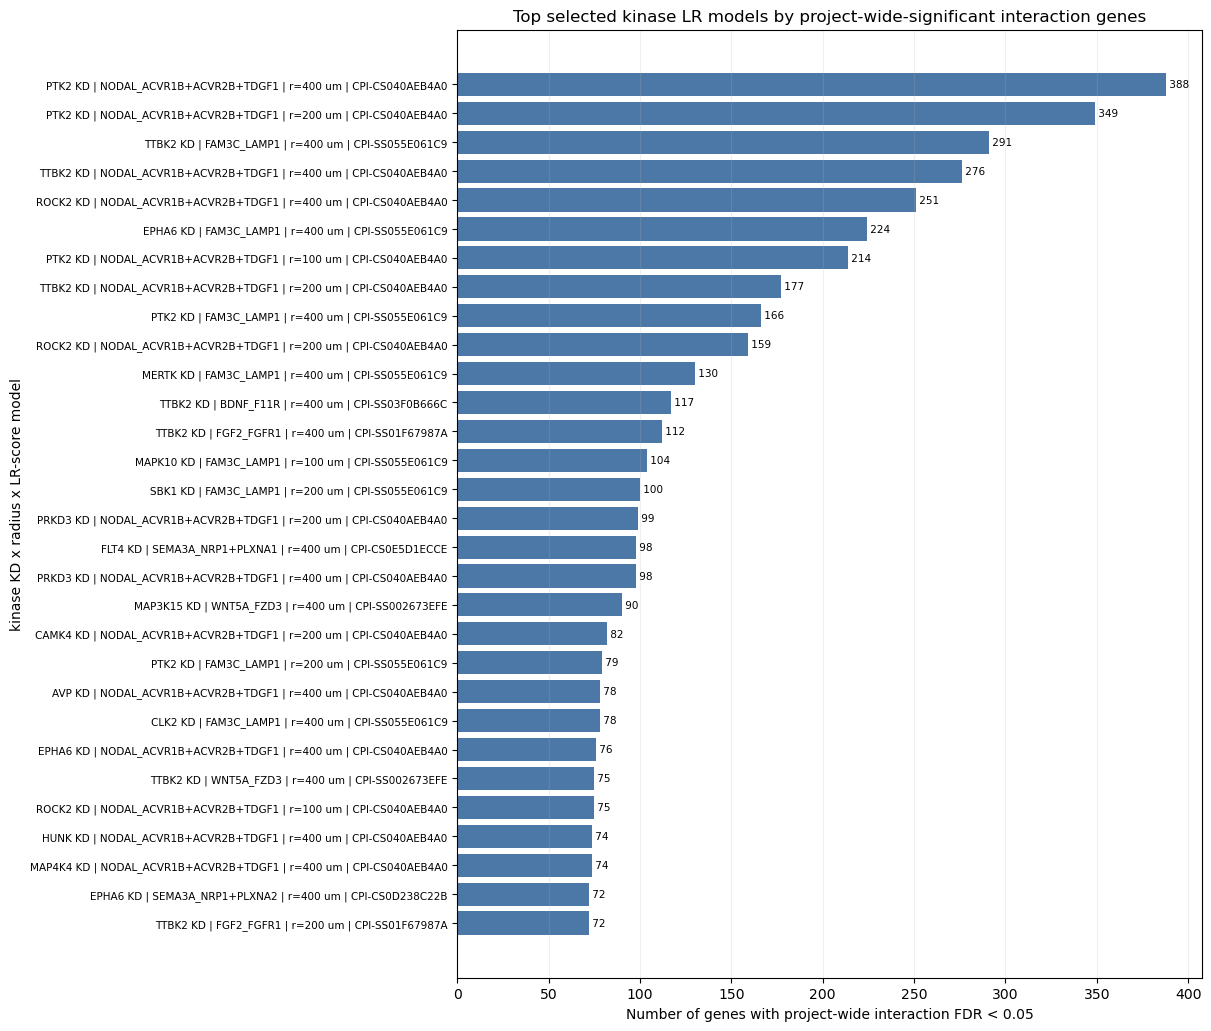

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank01__PTK2__AP000676.5__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank01__PTK2__AP000676.5__CPI-CS040AEB4A0_effect_trajectory.svg


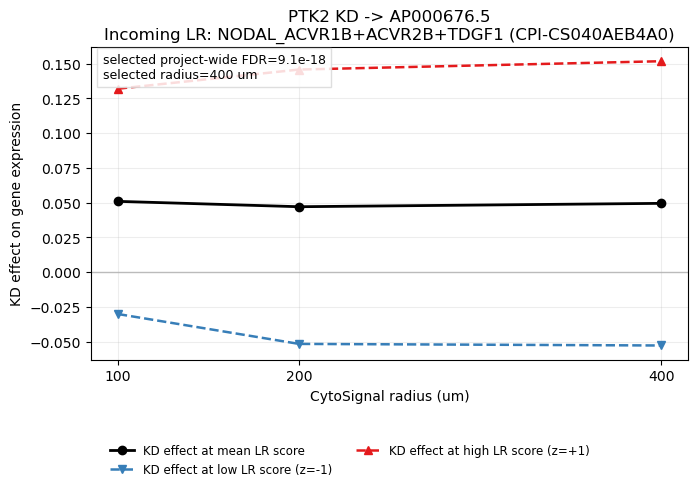

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank02__TTBK2__KCNQ1OT1__CPI-SS055E061C9_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank02__TTBK2__KCNQ1OT1__CPI-SS055E061C9_effect_trajectory.svg


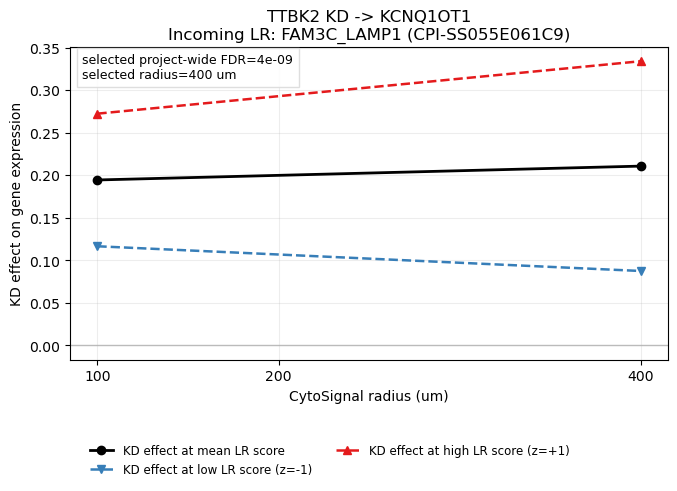

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank03__TTBK2__FBXL7__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank03__TTBK2__FBXL7__CPI-CS040AEB4A0_effect_trajectory.svg


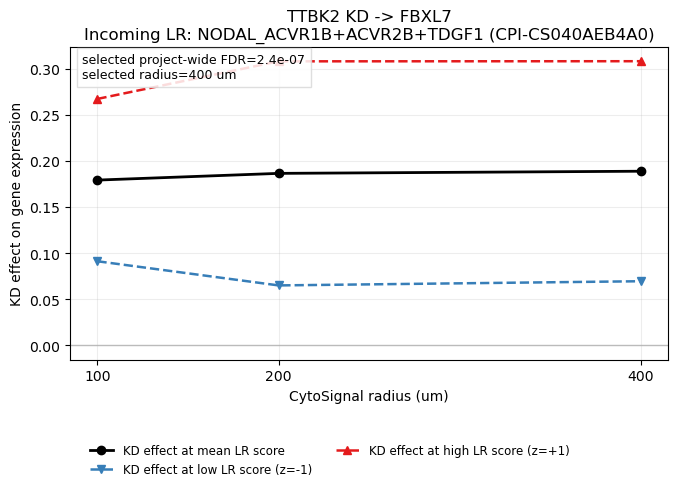

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank04__ROCK2__KAZN__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank04__ROCK2__KAZN__CPI-CS040AEB4A0_effect_trajectory.svg


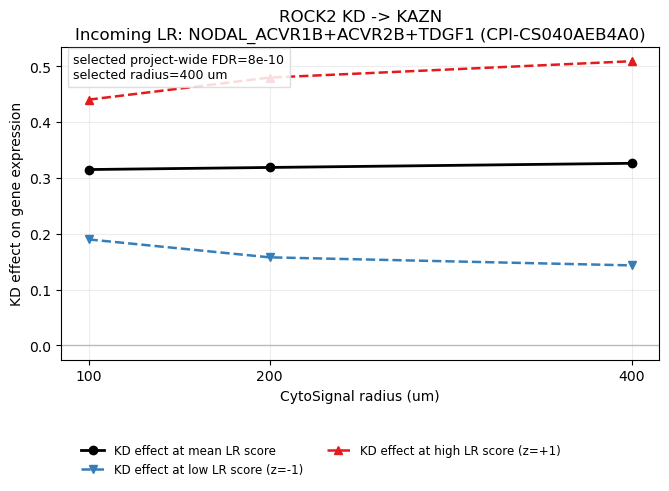

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank05__EPHA6__MALAT1__CPI-SS055E061C9_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank05__EPHA6__MALAT1__CPI-SS055E061C9_effect_trajectory.svg


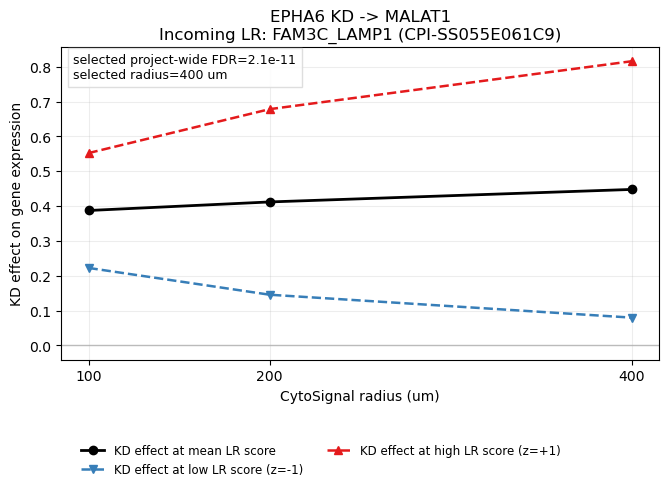

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank06__PTK2__AC068587.4__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank06__PTK2__AC068587.4__CPI-CS040AEB4A0_effect_trajectory.svg


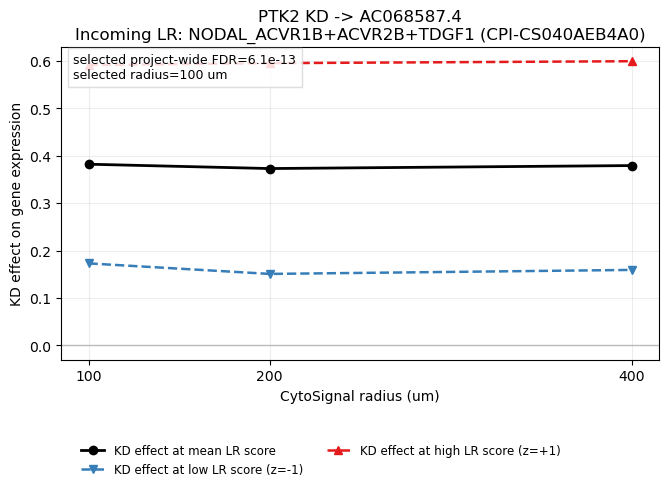

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank07__PTK2__NXN__CPI-SS055E061C9_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank07__PTK2__NXN__CPI-SS055E061C9_effect_trajectory.svg


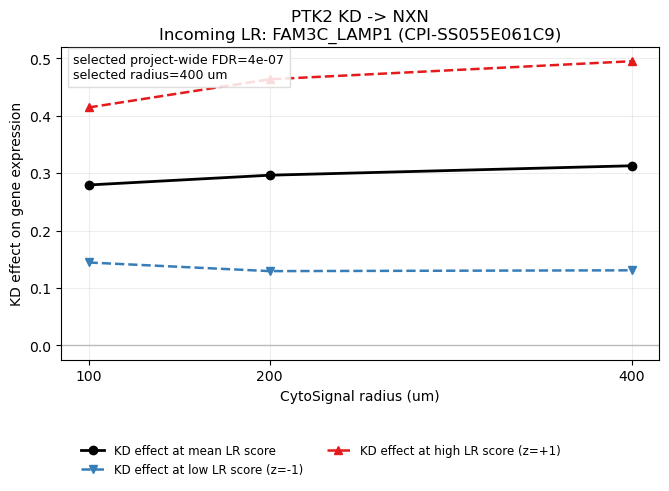

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank08__MERTK__EEF1A1__CPI-SS055E061C9_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank08__MERTK__EEF1A1__CPI-SS055E061C9_effect_trajectory.svg


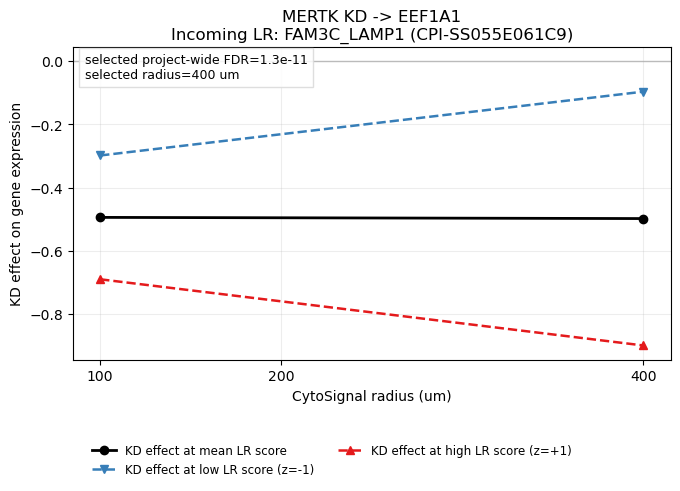

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank09__TTBK2__AL138720.1__CPI-SS03F0B666C_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank09__TTBK2__AL138720.1__CPI-SS03F0B666C_effect_trajectory.svg


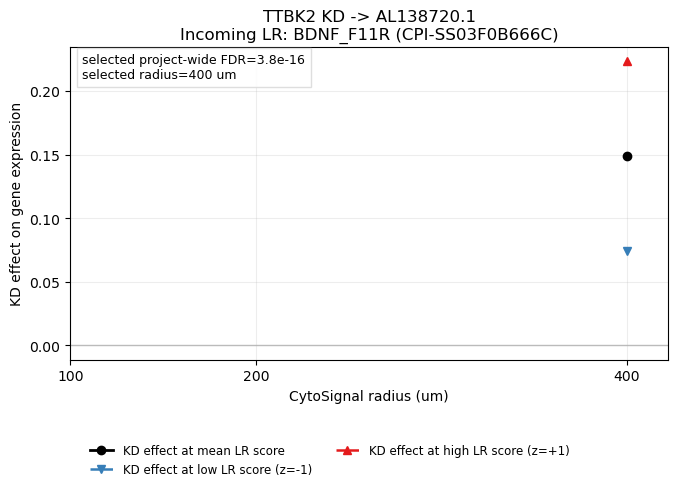

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank10__TTBK2__AL138720.1__CPI-SS01F67987A_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank10__TTBK2__AL138720.1__CPI-SS01F67987A_effect_trajectory.svg


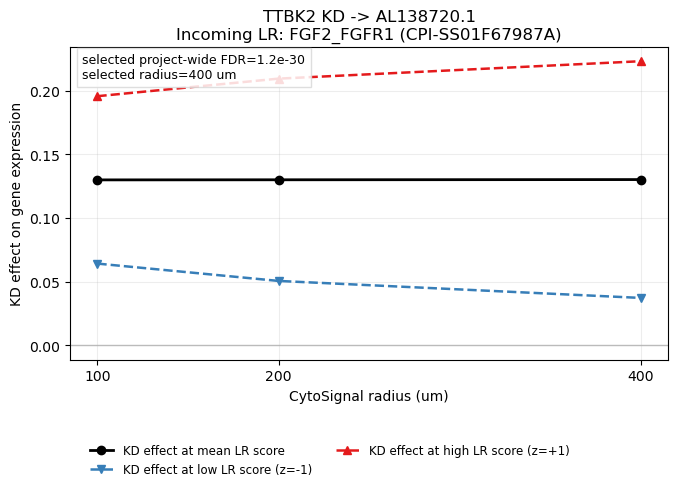

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank11__MAPK10__ARSK__CPI-SS055E061C9_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank11__MAPK10__ARSK__CPI-SS055E061C9_effect_trajectory.svg


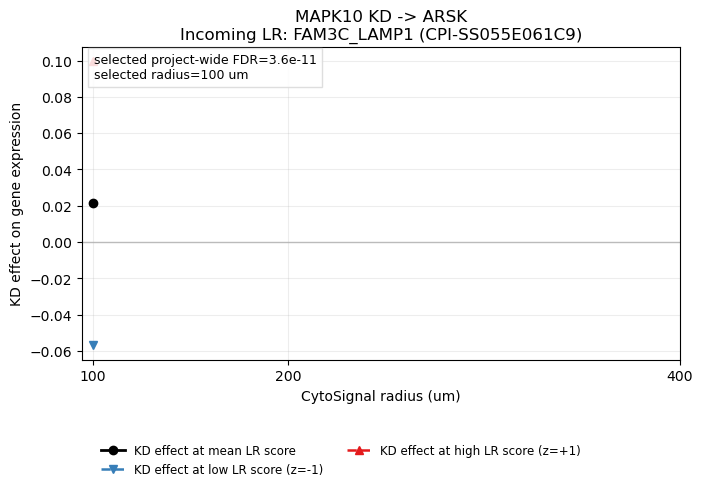

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank12__SBK1__EEF1A1__CPI-SS055E061C9_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank12__SBK1__EEF1A1__CPI-SS055E061C9_effect_trajectory.svg


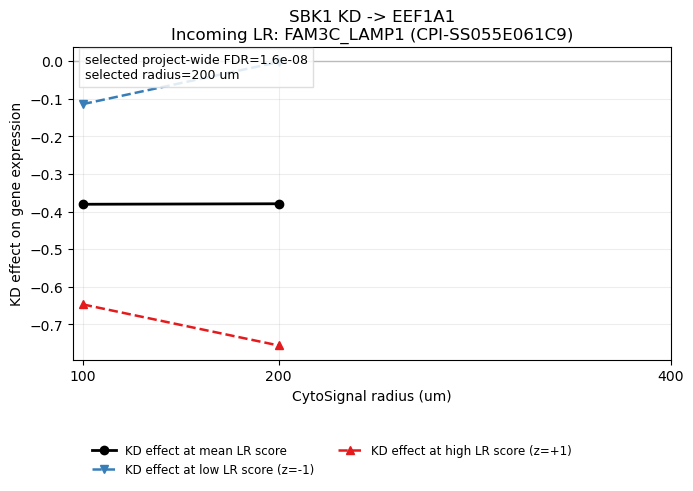

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank13__PRKD3__XACT__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank13__PRKD3__XACT__CPI-CS040AEB4A0_effect_trajectory.svg


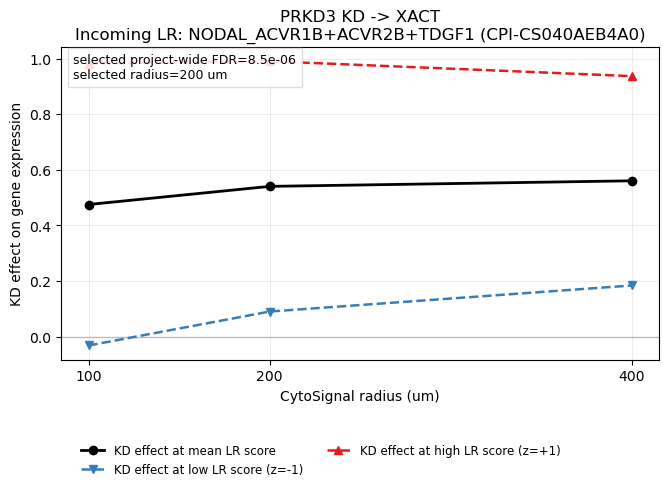

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank14__FLT4__KCTD13__CPI-CS0E5D1ECCE_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank14__FLT4__KCTD13__CPI-CS0E5D1ECCE_effect_trajectory.svg


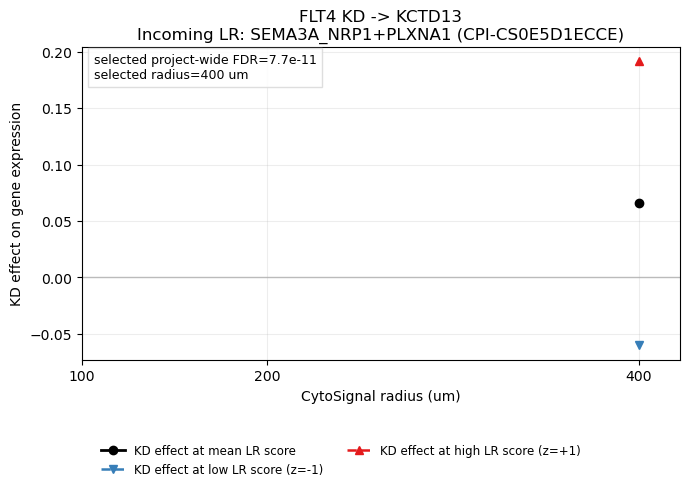

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank15__MAP3K15__NR2F1__CPI-SS002673EFE_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank15__MAP3K15__NR2F1__CPI-SS002673EFE_effect_trajectory.svg


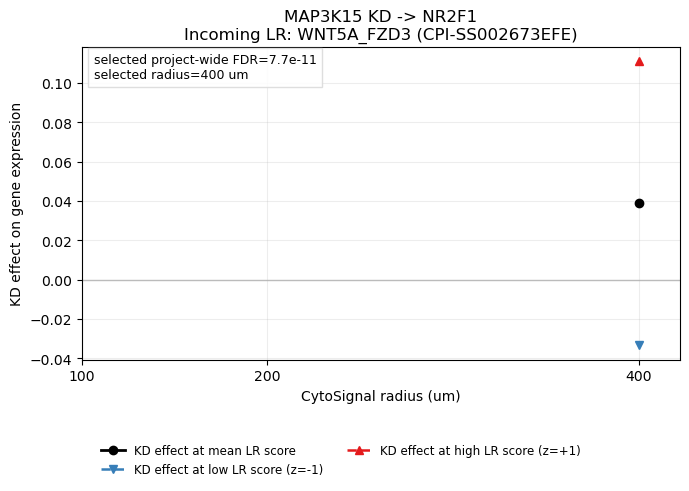

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank16__CAMK4__MYCBP2-AS1__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank16__CAMK4__MYCBP2-AS1__CPI-CS040AEB4A0_effect_trajectory.svg


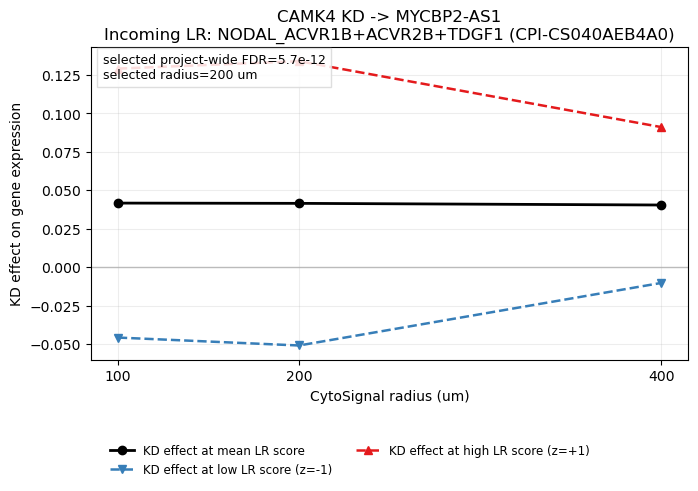

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank17__AVP__EEF1A1__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank17__AVP__EEF1A1__CPI-CS040AEB4A0_effect_trajectory.svg


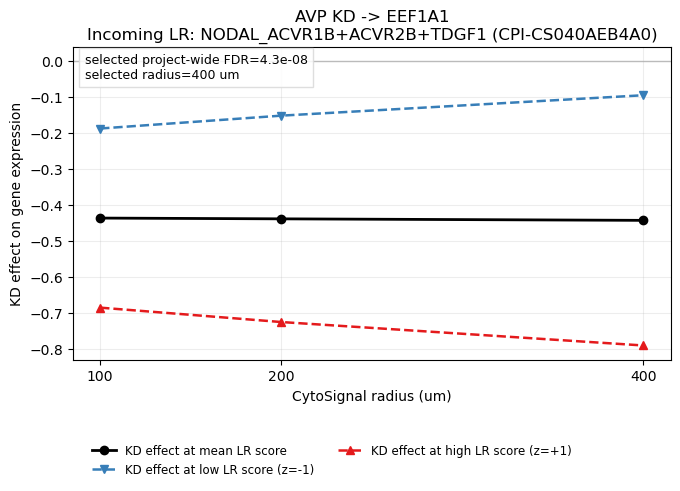

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank18__CLK2__AP001628.1__CPI-SS055E061C9_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank18__CLK2__AP001628.1__CPI-SS055E061C9_effect_trajectory.svg


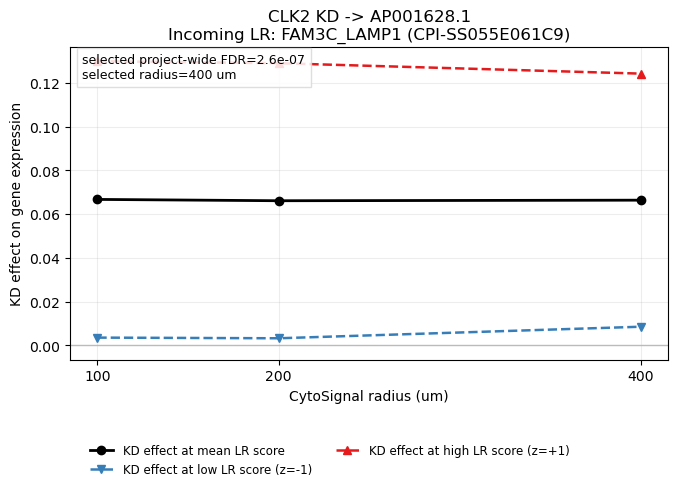

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank19__EPHA6__MIAT__CPI-CS040AEB4A0_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank19__EPHA6__MIAT__CPI-CS040AEB4A0_effect_trajectory.svg


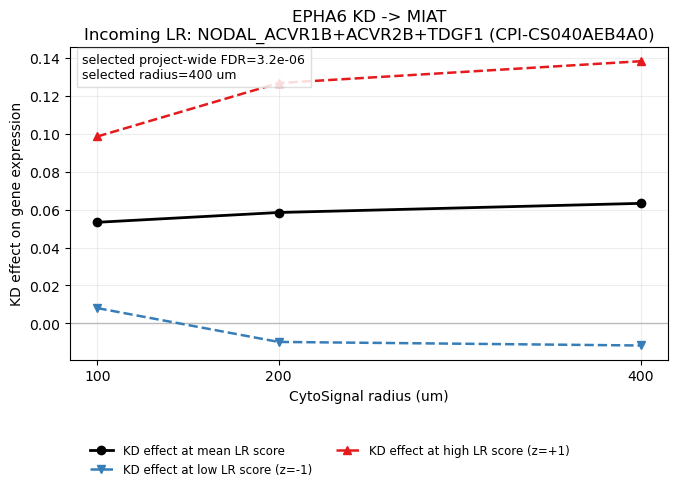

Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank20__TTBK2__GPR39__CPI-SS002673EFE_effect_trajectory.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures/rank20__TTBK2__GPR39__CPI-SS002673EFE_effect_trajectory.svg


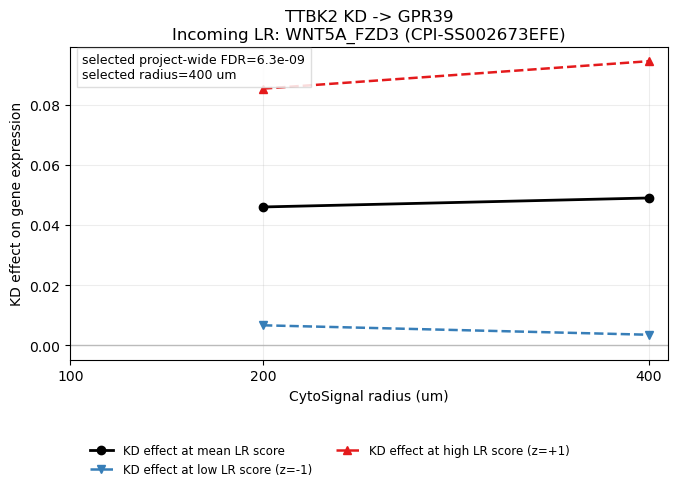

,target,radius_um,lr_var_name,n_genes_tested,n_projectwide_significant_interactions,minimum_p_interaction,minimum_fdr_interaction_projectwide,maximum_abs_beta_interaction,ligand_name,receptor_name,lr_name,elasticnet_importance,subset_lr_sd,subset_lr_nonzero_fraction,n_kd,n_control,lr_display_name,model_rank
0,PTK2,400,CPI-CS040AEB4A0,8864,388,2.778612e-24,9.086807e-18,0.220082,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.171940,0.287414,0.976609,686,5000,NODAL_ACVR1B+ACVR2B+TDGF1,1
1,PTK2,200,CPI-CS040AEB4A0,8864,349,4.071204e-22,6.656965e-16,0.222231,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,0.986793,0.333655,0.972740,686,5000,NODAL_ACVR1B+ACVR2B+TDGF1,2
2,TTBK2,400,CPI-SS055E061C9,8899,291,1.225816e-14,4.045526e-09,0.201595,NaN,NaN,FAM3C_LAMP1,0.825712,0.097443,0.984838,936,5000,FAM3C_LAMP1,3
3,TTBK2,400,CPI-CS040AEB4A0,8899,276,1.497587e-12,2.394339e-07,0.171653,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.044530,0.284042,0.978605,936,5000,NODAL_ACVR1B+ACVR2B+TDGF1,4
4,ROCK2,400,CPI-CS040AEB4A0,8894,251,1.826374e-15,8.012206e-10,0.182890,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.029755,0.284851,0.971975,852,5000,NODAL_ACVR1B+ACVR2B+TDGF1,5
5,EPHA6,400,CPI-SS055E061C9,8849,224,2.701533e-17,2.067705e-11,0.367867,NaN,NaN,FAM3C_LAMP1,0.766755,0.097610,0.986015,506,5000,FAM3C_LAMP1,6
6,PTK2,100,CPI-CS040AEB4A0,8864,214,6.617991e-19,6.104325e-13,0.209172,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,0.994679,0.399131,0.942314,686,5000,NODAL_ACVR1B+ACVR2B+TDGF1,7
7,TTBK2,200,CPI-CS040AEB4A0,8899,177,2.580997e-12,3.743794e-07,0.159315,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.045805,0.333841,0.973214,936,5000,NODAL_ACVR1B+ACVR2B+TDGF1,8
8,PTK2,400,CPI-SS055E061C9,8864,166,2.767451e-12,3.982136e-07,0.227430,NaN,NaN,FAM3C_LAMP1,0.840699,0.098126,0.984699,686,5000,FAM3C_LAMP1,9
9,ROCK2,200,CPI-CS040AEB4A0,8894,159,6.933296e-13,1.240851e-07,0.161015,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,0.968361,0.334314,0.971634,852,5000,NODAL_ACVR1B+ACVR2B+TDGF1,10


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd,se_kd,p_kd,beta_score,se_score,...,elasticnet_importance,fdr_kd_projectwide,fdr_score_projectwide,fdr_interaction_projectwide,source_file,model_rank,n_projectwide_significant_interactions,abs_beta_interaction,trajectory_rank,lr_display_name
0,PTK2,400,CPI-CS040AEB4A0,AP000676.5,0.091947,0.049498,0.011033,7.260768e-06,0.006474,0.001461,...,1.171940,3.011399e-04,1.271244e-05,9.086807e-18,PTK2__r400um__CPI-CS040AEB4A0_gene_level_ols.c...,1,388,0.102221,1,NODAL_ACVR1B+ACVR2B+TDGF1
1,TTBK2,400,CPI-SS055E061C9,KCNQ1OT1,0.351051,0.210760,0.016134,6.430050e-39,-0.003722,0.002443,...,0.825712,8.927360e-35,1.357415e-01,4.045526e-09,TTBK2__r400um__CPI-SS055E061C9_gene_level_ols....,3,291,0.123235,2,FAM3C_LAMP1
2,TTBK2,400,CPI-CS040AEB4A0,FBXL7,0.370980,0.189063,0.016476,1.961684e-30,0.022590,0.002497,...,1.044530,1.294343e-26,4.360638e-19,2.394339e-07,TTBK2__r400um__CPI-CS040AEB4A0_gene_level_ols....,4,276,0.119349,3,NODAL_ACVR1B+ACVR2B+TDGF1
3,ROCK2,400,CPI-CS040AEB4A0,KAZN,0.550728,0.326384,0.023458,6.669164e-44,0.037985,0.003442,...,1.029755,1.397260e-39,1.162077e-27,8.012206e-10,ROCK2__r400um__CPI-CS040AEB4A0_gene_level_ols....,5,251,0.182890,4,NODAL_ACVR1B+ACVR2B+TDGF1
4,EPHA6,400,CPI-SS055E061C9,MALAT1,0.994342,0.447802,0.036059,2.418915e-35,0.117465,0.004021,...,0.766755,2.473437e-31,6.957613e-184,2.067705e-11,EPHA6__r400um__CPI-SS055E061C9_gene_level_ols....,6,224,0.367867,5,FAM3C_LAMP1
5,PTK2,100,CPI-CS040AEB4A0,AC068587.4,0.501223,0.382342,0.024879,3.831656e-53,0.036443,0.003293,...,0.994679,2.088424e-48,8.241328e-28,6.104325e-13,PTK2__r100um__CPI-CS040AEB4A0_gene_level_ols.c...,7,214,0.209172,6,NODAL_ACVR1B+ACVR2B+TDGF1
6,PTK2,400,CPI-SS055E061C9,NXN,0.523726,0.312916,0.023530,2.891020e-40,0.034832,0.002963,...,0.840699,4.463457e-36,3.576622e-31,3.982136e-07,PTK2__r400um__CPI-SS055E061C9_gene_level_ols.c...,9,166,0.182026,7,FAM3C_LAMP1
7,MERTK,400,CPI-SS055E061C9,EEF1A1,0.928372,-0.498101,0.076078,5.932854e-11,0.421790,0.003906,...,0.654341,1.423366e-08,0.000000e+00,1.304777e-11,MERTK__r400um__CPI-SS055E061C9_gene_level_ols....,11,130,0.401785,8,FAM3C_LAMP1
8,TTBK2,400,CPI-SS03F0B666C,AL138720.1,0.107749,0.148820,0.008615,1.289833e-66,0.018506,0.001331,...,0.868608,3.932128e-61,5.154255e-43,3.750833e-16,TTBK2__r400um__CPI-SS03F0B666C_gene_level_ols....,12,117,0.074694,9,BDNF_F11R
9,TTBK2,400,CPI-SS01F67987A,AL138720.1,0.107749,0.130291,0.008603,1.149658e-51,0.034594,0.001322,...,1.055048,5.329458e-47,5.472305e-148,1.164354e-30,TTBK2__r400um__CPI-SS01F67987A_gene_level_ols....,13,112,0.092937,10,FGF2_FGFR1


,file,path
0,rank01__PTK2__AP000676.5__CPI-CS040AEB4A0_effe...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
1,rank02__TTBK2__KCNQ1OT1__CPI-SS055E061C9_effec...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
2,rank03__TTBK2__FBXL7__CPI-CS040AEB4A0_effect_t...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
3,rank04__ROCK2__KAZN__CPI-CS040AEB4A0_effect_tr...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
4,rank05__EPHA6__MALAT1__CPI-SS055E061C9_effect_...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
5,rank06__PTK2__AC068587.4__CPI-CS040AEB4A0_effe...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
6,rank07__PTK2__NXN__CPI-SS055E061C9_effect_traj...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
7,rank08__MERTK__EEF1A1__CPI-SS055E061C9_effect_...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
8,rank09__TTBK2__AL138720.1__CPI-SS03F0B666C_eff...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
9,rank10__TTBK2__AL138720.1__CPI-SS01F67987A_eff...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...


,file,path
0,rank01__PTK2__AP000676.5__CPI-CS040AEB4A0_effe...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
1,rank02__TTBK2__KCNQ1OT1__CPI-SS055E061C9_effec...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
2,rank03__TTBK2__FBXL7__CPI-CS040AEB4A0_effect_t...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
3,rank04__ROCK2__KAZN__CPI-CS040AEB4A0_effect_tr...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
4,rank05__EPHA6__MALAT1__CPI-SS055E061C9_effect_...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
5,rank06__PTK2__AC068587.4__CPI-CS040AEB4A0_effe...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
6,rank07__PTK2__NXN__CPI-SS055E061C9_effect_traj...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
7,rank08__MERTK__EEF1A1__CPI-SS055E061C9_effect_...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
8,rank09__TTBK2__AL138720.1__CPI-SS03F0B666C_eff...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...
9,rank10__TTBK2__AL138720.1__CPI-SS01F67987A_eff...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...


Publication PDF/SVG output directory: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results/projectwide_publication_pdf_svg_figures


In [1]:
from pathlib import Path
import json
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

PUBLICATION_RESULT_DIR = Path('/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results')
PUBLICATION_FDR_POINTER = PUBLICATION_RESULT_DIR / 'projectwide_fdr_posthoc' / 'LATEST_PROJECTWIDE_FDR.json'
PUBLICATION_FIGURE_DIR = PUBLICATION_RESULT_DIR / 'projectwide_publication_pdf_svg_figures'
PUBLICATION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PUBLICATION_TOP_N_MODELS = 30
PUBLICATION_TOP_N_TRAJECTORIES = 20
PUBLICATION_FDR_ALPHA = 0.05
PUBLICATION_RADII = [100, 200, 400]

if not PUBLICATION_RESULT_DIR.is_dir():
    raise FileNotFoundError(PUBLICATION_RESULT_DIR)
if not PUBLICATION_FDR_POINTER.is_file():
    raise RuntimeError(
        'Completed project-wide FDR output was not found. Run the project-wide FDR section first: '
        f'{PUBLICATION_FDR_POINTER}'
    )

publication_metadata = json.loads(PUBLICATION_FDR_POINTER.read_text())
if publication_metadata.get('status') != 'completed':
    raise RuntimeError(f'Project-wide FDR is incomplete: {publication_metadata}')
publication_run_dir = Path(publication_metadata['run_dir'])
publication_summary_path = publication_run_dir / 'projectwide_interaction_summary.csv'
publication_events_path = publication_run_dir / 'projectwide_significant_interaction_events.csv.gz'
publication_annotation_path = PUBLICATION_RESULT_DIR / 'input_candidate_lr_scores.csv'
for required_path in [publication_summary_path, publication_events_path, publication_annotation_path]:
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

publication_model_summary = pd.read_csv(publication_summary_path)
publication_events = pd.read_csv(publication_events_path)
publication_annotation = pd.read_csv(publication_annotation_path)

model_key = ['target', 'radius_um', 'lr_var_name']
event_key = model_key + ['gene']
for frame in [publication_model_summary, publication_events, publication_annotation]:
    frame['target'] = frame['target'].astype(str).str.upper()
    frame['radius_um'] = frame['radius_um'].astype(int)
    frame['lr_var_name'] = frame['lr_var_name'].astype(str)
if publication_annotation.duplicated(model_key).any():
    publication_annotation = publication_annotation.sort_values(model_key).drop_duplicates(model_key, keep='first')

annotation_columns = model_key + [
    column for column in ['ligand_name', 'receptor_name', 'lr_name', 'elasticnet_importance', 'subset_lr_sd', 'subset_lr_nonzero_fraction', 'n_kd', 'n_control']
    if column in publication_annotation.columns
]
publication_model_summary = publication_model_summary.merge(
    publication_annotation[annotation_columns],
    on=model_key,
    how='left',
    validate='one_to_one',
)


def _publication_lr_display(frame):
    ligand = frame.get('ligand_name', pd.Series('', index=frame.index)).fillna('').astype(str).str.strip()
    receptor = frame.get('receptor_name', pd.Series('', index=frame.index)).fillna('').astype(str).str.strip()
    lr_name = frame.get('lr_name', pd.Series('', index=frame.index)).fillna('').astype(str).str.strip()
    return np.where(
        ligand.ne('') & receptor.ne(''),
        ligand + ' -> ' + receptor,
        np.where(lr_name.ne(''), lr_name, frame['lr_var_name'].astype(str)),
    )

publication_model_summary['lr_display_name'] = _publication_lr_display(publication_model_summary)
publication_model_summary = publication_model_summary.loc[
    publication_model_summary['n_projectwide_significant_interactions'].gt(0)
].copy()
publication_model_summary = publication_model_summary.sort_values(
    ['n_projectwide_significant_interactions', 'minimum_fdr_interaction_projectwide'],
    ascending=[False, True],
    ignore_index=True,
)
top_publication_models = publication_model_summary.head(PUBLICATION_TOP_N_MODELS).copy()
top_publication_models['model_rank'] = np.arange(1, len(top_publication_models) + 1)
top_publication_models.to_csv(
    PUBLICATION_FIGURE_DIR / 'top_projectwide_significant_lr_models.csv',
    index=False,
)

if top_publication_models.empty:
    raise RuntimeError('No kinase LR model has a project-wide-significant interaction gene.')

# Figure 1: overview of top LR models by significant interaction-gene count.
overview = top_publication_models.iloc[::-1].copy()
overview['plot_label'] = (
    overview['target'].astype(str) + ' KD | '
    + overview['lr_display_name'].astype(str) + ' | r='
    + overview['radius_um'].astype(str) + ' um | '
    + overview['lr_var_name'].astype(str)
)
fig, ax = plt.subplots(
    figsize=(12, max(6.5, 0.34 * len(overview))),
    constrained_layout=True,
)
bars = ax.barh(
    np.arange(len(overview)),
    overview['n_projectwide_significant_interactions'],
    color='#4C78A8',
)
ax.set_yticks(np.arange(len(overview)))
ax.set_yticklabels(overview['plot_label'], fontsize=7.5)
ax.set_xlabel('Number of genes with project-wide interaction FDR < 0.05')
ax.set_ylabel('kinase KD x radius x LR-score model')
ax.set_title('Top selected kinase LR models by project-wide-significant interaction genes')
ax.grid(axis='x', alpha=0.2)
for bar, count in zip(bars, overview['n_projectwide_significant_interactions']):
    ax.text(
        bar.get_width(), bar.get_y() + bar.get_height() / 2,
        f' {int(count)}', ha='left', va='center', fontsize=7.5,
    )
overview_pdf_path = PUBLICATION_FIGURE_DIR / 'top_selected_lr_models_projectwide_significant_gene_counts.pdf'
overview_svg_path = PUBLICATION_FIGURE_DIR / 'top_selected_lr_models_projectwide_significant_gene_counts.svg'
fig.savefig(overview_pdf_path, format='pdf', bbox_inches='tight')
fig.savefig(overview_svg_path, format='svg', bbox_inches='tight')
print('Saved:', overview_pdf_path)
print('Saved:', overview_svg_path)
plt.show()

# Select one strongest project-wide-significant gene event from the highest-ranked models.
publication_events['gene'] = publication_events['gene'].astype(str)
publication_events = publication_events.loc[
    publication_events['fdr_interaction_projectwide'].lt(PUBLICATION_FDR_ALPHA)
].copy()
candidate_model_ranks = top_publication_models[model_key + ['model_rank', 'n_projectwide_significant_interactions']]
publication_event_candidates = publication_events.merge(
    candidate_model_ranks,
    on=model_key,
    how='inner',
    validate='many_to_one',
)
publication_event_candidates['abs_beta_interaction'] = pd.to_numeric(
    publication_event_candidates['beta_interaction'], errors='coerce'
).abs()
publication_event_candidates = publication_event_candidates.sort_values(
    ['model_rank', 'fdr_interaction_projectwide', 'abs_beta_interaction'],
    ascending=[True, True, False],
)
top_publication_events = (
    publication_event_candidates
    .drop_duplicates(model_key, keep='first')
    .drop_duplicates(['target', 'lr_var_name', 'gene'], keep='first')
    .head(PUBLICATION_TOP_N_TRAJECTORIES)
    .reset_index(drop=True)
)
top_publication_events['trajectory_rank'] = np.arange(1, len(top_publication_events) + 1)
top_publication_events['lr_display_name'] = _publication_lr_display(top_publication_events)
top_publication_events.to_csv(
    PUBLICATION_FIGURE_DIR / 'top_projectwide_significant_trajectory_candidates.csv',
    index=False,
)


def _publication_safe_name(value):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(value)).strip('_')


def _publication_read_gene_event(target, radius_um, lr_var_name, gene):
    path = PUBLICATION_RESULT_DIR / (
        f'{_publication_safe_name(target)}__r{int(radius_um)}um__'
        f'{_publication_safe_name(lr_var_name)}_gene_level_ols.csv.gz'
    )
    if not path.is_file():
        return None
    try:
        frame = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return None
    hit = frame.loc[frame['gene'].astype(str).eq(str(gene))]
    if hit.empty:
        return None
    row = hit.iloc[0].to_dict()
    row['result_file'] = str(path)
    return row

publication_trajectory_rows = []
for _, candidate in top_publication_events.iterrows():
    target = str(candidate['target'])
    lr_var_name = str(candidate['lr_var_name'])
    gene = str(candidate['gene'])
    for radius_um in PUBLICATION_RADII:
        row = _publication_read_gene_event(target, radius_um, lr_var_name, gene)
        if row is None:
            continue
        row['trajectory_rank'] = int(candidate['trajectory_rank'])
        row['selected_model_radius_um'] = int(candidate['radius_um'])
        row['selected_fdr_interaction_projectwide'] = float(candidate['fdr_interaction_projectwide'])
        row['selected_n_projectwide_significant_interactions'] = int(candidate['n_projectwide_significant_interactions'])
        row['trajectory_target'] = target
        row['trajectory_lr_var_name'] = lr_var_name
        row['trajectory_lr_display_name'] = str(candidate['lr_display_name'])
        row['trajectory_gene'] = gene
        row['radius_um'] = int(radius_um)
        if 'conditional_kd_effect_low_score' not in row or pd.isna(row.get('conditional_kd_effect_low_score')):
            row['conditional_kd_effect_low_score'] = row['beta_kd'] - row['beta_interaction']
        if 'conditional_kd_effect_high_score' not in row or pd.isna(row.get('conditional_kd_effect_high_score')):
            row['conditional_kd_effect_high_score'] = row['beta_kd'] + row['beta_interaction']
        row['trajectory_point_type'] = 'spatial_lr_model'
        publication_trajectory_rows.append(row)

publication_trajectory = pd.DataFrame(publication_trajectory_rows)
if not publication_trajectory.empty:
    publication_trajectory = publication_trajectory.sort_values(
        ['trajectory_rank', 'radius_um'], ignore_index=True
    )
publication_trajectory.to_csv(
    PUBLICATION_FIGURE_DIR / 'top_projectwide_significant_effect_trajectories.csv',
    index=False,
)

if publication_trajectory.empty:
    print('No project-wide-significant trajectory data were available.')
else:
    for trajectory_rank, sub in publication_trajectory.groupby('trajectory_rank', sort=True):
        sub = sub.sort_values('radius_um')
        first = sub.iloc[0]
        target = str(first['trajectory_target'])
        gene = str(first['trajectory_gene'])
        lr_var_name = str(first['trajectory_lr_var_name'])
        lr_display_name = str(first['trajectory_lr_display_name'])
        fig, ax = plt.subplots(figsize=(7.2, 5.3), constrained_layout=False)
        ax.axhline(0, color='0.75', linewidth=1, zorder=0)
        kd_line = sub[['radius_um', 'beta_kd']].dropna().sort_values('radius_um')
        ax.plot(
            kd_line['radius_um'], kd_line['beta_kd'],
            color='black', marker='o', linewidth=2.0,
            label='KD effect at mean LR score',
        )
        ax.plot(
            sub['radius_um'], sub['conditional_kd_effect_low_score'],
            color='#377EB8', marker='v', linestyle='--', linewidth=1.8,
            label='KD effect at low LR score (z=-1)',
        )
        ax.plot(
            sub['radius_um'], sub['conditional_kd_effect_high_score'],
            color='#E41A1C', marker='^', linestyle='--', linewidth=1.8,
            label='KD effect at high LR score (z=+1)',
        )
        ax.set_xticks(PUBLICATION_RADII)
        ax.set_xlabel('CytoSignal radius (um)')
        ax.set_ylabel('KD effect on gene expression')
        ax.set_title(
            f'{target} KD -> {gene}\nIncoming LR: {lr_display_name} ({lr_var_name})'
        )
        ax.grid(alpha=0.22)
        ax.text(
            0.02, 0.98,
            f"selected project-wide FDR={first['selected_fdr_interaction_projectwide']:.2g}\n"
            f"selected radius={int(first['selected_model_radius_um'])} um",
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='0.85', alpha=0.85),
        )
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        fig.legend(
            unique.values(), unique.keys(),
            loc='lower center', bbox_to_anchor=(0.5, 0.01),
            ncol=2, frameon=False, fontsize=8.5,
        )
        fig.subplots_adjust(left=0.14, right=0.97, top=0.84, bottom=0.25)
        stem = (
            f'rank{int(trajectory_rank):02d}__{_publication_safe_name(target)}__'
            f'{_publication_safe_name(gene)}__{_publication_safe_name(lr_var_name)}_effect_trajectory'
        )
        trajectory_pdf_path = PUBLICATION_FIGURE_DIR / f'{stem}.pdf'
        trajectory_svg_path = PUBLICATION_FIGURE_DIR / f'{stem}.svg'
        fig.savefig(trajectory_pdf_path, format='pdf', bbox_inches='tight')
        fig.savefig(trajectory_svg_path, format='svg', bbox_inches='tight')
        print('Saved:', trajectory_pdf_path)
        print('Saved:', trajectory_svg_path)
        plt.show()

publication_figure_manifest = pd.DataFrame({
    'file': [path.name for path in sorted(PUBLICATION_FIGURE_DIR.glob('*.pdf'))],
    'path': [str(path) for path in sorted(PUBLICATION_FIGURE_DIR.glob('*.pdf'))],
})
publication_figure_manifest.to_csv(
    PUBLICATION_FIGURE_DIR / 'publication_pdf_figure_manifest.csv',
    index=False,
)

publication_svg_manifest = pd.DataFrame({
    'file': [path.name for path in sorted(PUBLICATION_FIGURE_DIR.glob('*.svg'))],
    'path': [str(path) for path in sorted(PUBLICATION_FIGURE_DIR.glob('*.svg'))],
})
publication_svg_manifest.to_csv(
    PUBLICATION_FIGURE_DIR / 'publication_svg_figure_manifest.csv',
    index=False,
)

display(top_publication_models.head(30))
display(top_publication_events)
display(publication_figure_manifest)
display(publication_svg_manifest)
print('Publication PDF/SVG output directory:', PUBLICATION_FIGURE_DIR)
